In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> `src/pipelines/02_fnd_eda_notebooks/01_ukdale_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 01 · UK-DALE — four years of one London home

**Dataset:** UK-DALE (Kelly & Knowlton, *BuildSys* 2015, CC-BY 4.0) — five London homes, 2012–2017, held here as raw-fidelity Parquet under `data/fnd/ukdale/`. **Role:** the primary training/evaluation substrate for appliance-level disaggregation.

> How to read: every section below starts from a question, answers it from the raw files, then interprets
> the answer. Charts are rendered — read top-to-bottom without executing anything. No number is hard-coded.

In [ ]:
import sys, os
import numpy as np
import pandas as pd
import eda_fnd_lib as eda
eda.apply_style()
print("python:", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print("repo:", eda.ROOT)

python: 3.13.7 | pandas 3.0.6 | numpy 2.5.3
repo: /root/longvdh/agent_space/projects/watt-wiser


## Meet the dataset

UK-DALE recorded **five real London homes between 2012 and 2017** for exactly the problem this project studies: appliance-level electricity from meter data. Two instrument classes were installed:

- a meter on the **incoming supply** recording total active power **every second** (houses 1, 2 and 5; house 1 also logs apparent power and voltage),
- small meters on **individual appliances** — a fridge here, the kettle there — recording roughly **every 6 seconds**.

What we hold is the raw recording, unmodified: one Parquet file per meter (`ts_us` = UTC microseconds, `v0` = active watts), a `labels.dat` mapping channel numbers to appliance names, and sparse "button press" interaction logs. Nothing resampled, nothing cleaned. The table below is computed from Parquet metadata only.

Why this dataset matters to this project: in the target deployment only the aggregate is collectable. Recordings like these - with appliance-level ground truth - are how we learn what the aggregate is made of and what a model is being asked to infer. Sections tagged **[insight only]** exist for that understanding; **[collectable]** marks what we can record ourselves.

In [ ]:
import glob
import pyarrow.parquet as pq
house_dirs = sorted(glob.glob(eda.fnd_file('ukdale', 'house_*')))
inv = []
inv_rows_total = []
for _hd in house_dirs:
    hname = os.path.basename(_hd)
    files = glob.glob(os.path.join(_hd, 'channel_*.parquet'))
    chans = [f for f in files if 'button' not in os.path.basename(f)]
    total = sum((pq.ParquetFile(f).metadata.num_rows for f in chans))
    has_mains = os.path.exists(os.path.join(_hd, 'mains.parquet'))
    span_txt = '-'
    if chans:
        biggest = max(chans, key=lambda f: pq.ParquetFile(f).metadata.num_rows)
        meta = pq.ParquetFile(biggest).metadata
        sa = meta.row_group(0).column(0).statistics
        sb = meta.row_group(meta.num_row_groups - 1).column(0).statistics
        if sa and sa.min is not None and sb and (sb.max is not None):
            _span_d = (sb.max - sa.min) / 86400000000.0
            span_txt = '%.1f y (from %s)' % (_span_d / 365.25, pd.to_datetime(sa.min, unit='us').strftime('%Y-%m'))
    inv.append([hname, len(chans), 'yes' if has_mains else 'no', span_txt, eda.fmt_int(total)])
    inv_rows_total.append(total)
mo.md(eda.md_table(['house', 'channels', 'mains', 'span', 'channel rows'], inv))

| house | channels | mains | span | channel rows |
| --- | --- | --- | --- | --- |
| house_1 | 53 | yes | 4.5 y (from 2012-11) | 728,877,165 |
| house_2 | 19 | yes | 0.6 y (from 2013-02) | 40,506,387 |
| house_3 | 5 | no | 0.1 y (from 2013-02) | 2,581,158 |
| house_4 | 6 | no | 0.6 y (from 2013-03) | 13,088,208 |
| house_5 | 25 | yes | 0.4 y (from 2014-06) | 33,903,991 |

House 1 is the flagship — 4.1 years of mains plus 53 labelled channels — so this notebook walks through it.

## A day in the life

*What does the aggregate signal of a real home actually look like?*

The supply meter wrote **128 million one-second readings** between 2013-03 and 2017-04 — 12,268 kWh of electricity. The scan below streams every row once (quantiles from a uniform 2M-sample decimation); then we look at three days up close and at the average day.

In [ ]:
mains_path = eda.fnd_file("ukdale", "house_1", "mains.parquet")
scan = eda.scan_power_series(mains_path, value_col="v0", local_offset_hours=0)
mo.md(eda.md_scan_stats(scan, "UK-DALE house_1 mains (active W @ 1 s)"))

| metric | value |
| --- | --- |
| series | UK-DALE house_1 mains (active W @ 1 s) |
| rows | 128,238,700 (missing 0) |
| span | 1500.9 days |
| cadence | median 1.00 s, p90 1.10 s, gap fraction 0.000 |
| power W | mean 342.5, p50 223.3, p95 693.3, p99 2710.7, max 8066 |
| energy | 12268.0 kWh |
| steps per day | >=30 W 1542.3, >=100 W 709.9, >=300 W 179.3 |

weekday mean 346 W | weekend mean 333 W | weekend/weekday 0.96 (whole span, UTC days)


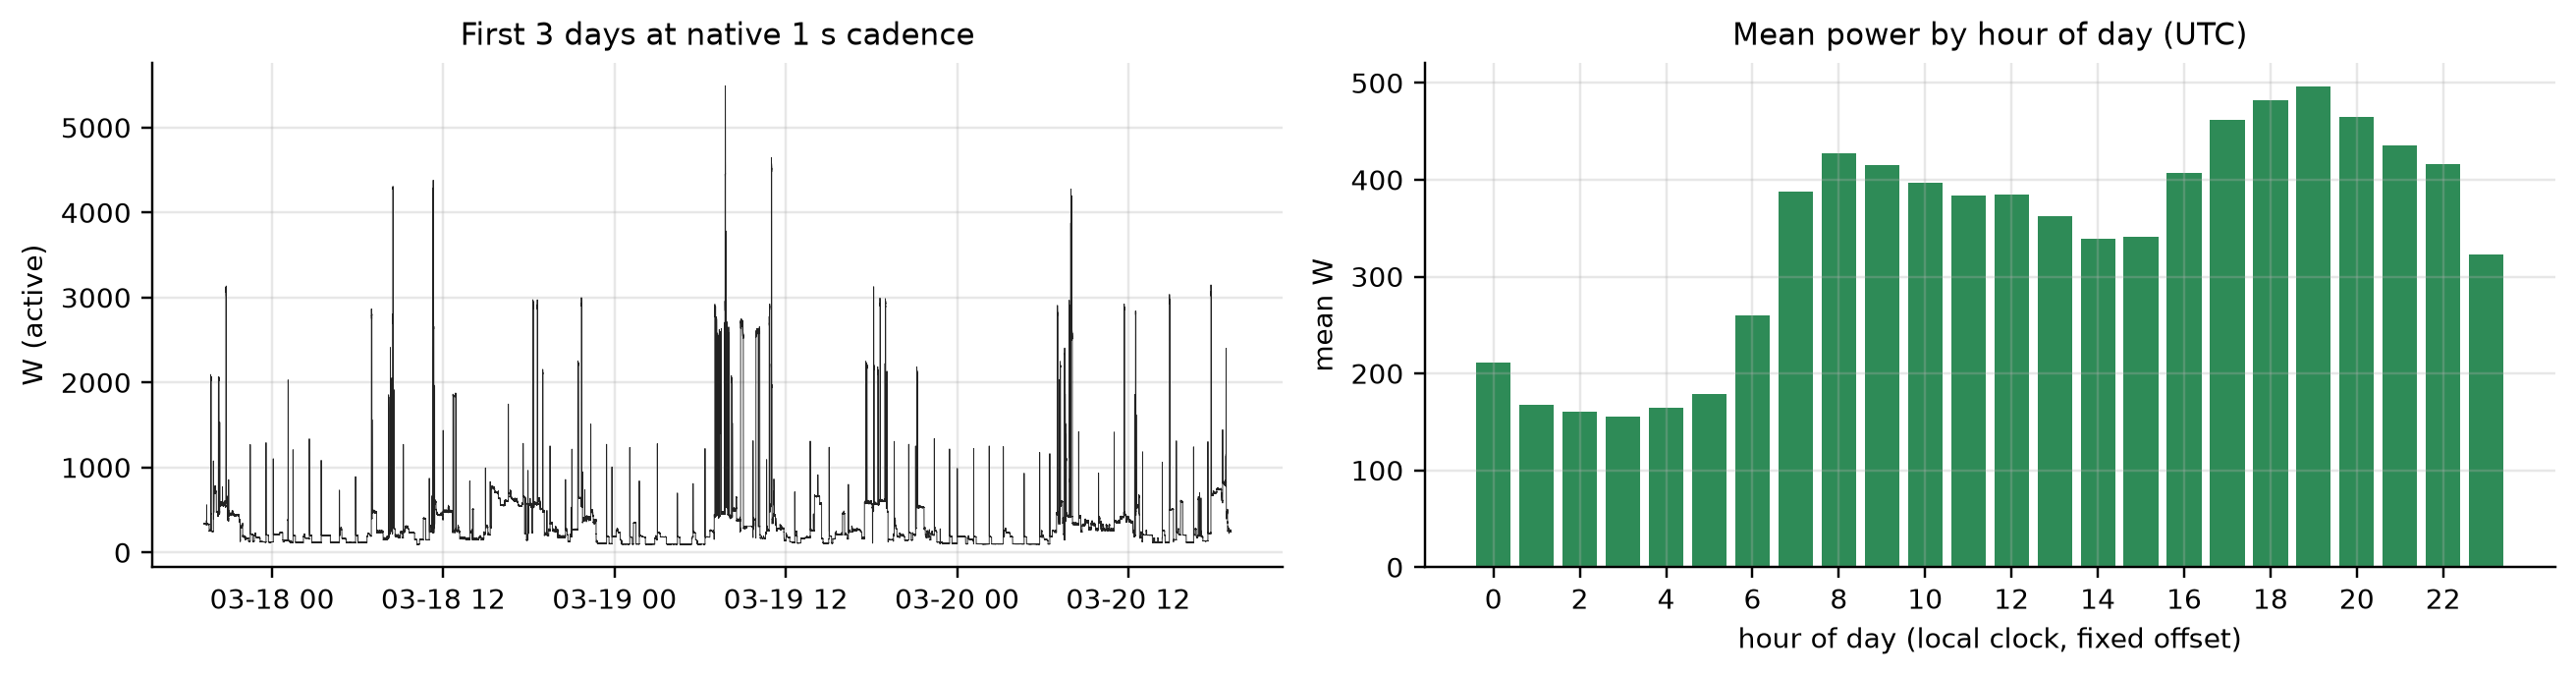

In [ ]:
import matplotlib.pyplot as plt
_fig, _ax = plt.subplots(1, 2, figsize=(12, 3.2))
eda.fig_zoom(scan, ax=_ax[0], title='First 3 days at native 1 s cadence')
eda.fig_diurnal(scan, ax=_ax[1], title='Mean power by hour of day (UTC)')
_fig.tight_layout()
wk_mean = scan['weekday']
weekday_mean = float(wk_mean[:5].mean())
weekend_mean = float(wk_mean[5:].mean())
print('weekday mean %.0f W | weekend mean %.0f W | weekend/weekday %.2f (whole span, UTC days)' % (weekday_mean, weekend_mean, weekend_mean / weekday_mean))
_fig  # render figure as cell output

**Reading it.** The load never switches off: an overnight floor around 150–160 W (standby electronics plus the fridge ticking over) rises through the morning, and the evening peak reaches ~500 W on average around 19–20 h. On top of that floor sit short spikes of 2–5 kW — kettle boils, a shower, the hob — lasting seconds to minutes. The mean (342 W) sits far above the median (223 W) and p99 is 2.7 kW: demand is bursts, not a steady draw. This asymmetry is why a mean alone never summarises a home. Two more structural reads: weekends run a few percent lighter than weekdays (printed above), and every hour-of-day statistic here is **UTC** — add one hour for British Summer Time, which applies to the zoom windows below (late April).

## Q1 — Is anything missing?

*Before trusting any statistic: what did the logger actually miss?*

One streaming pass over the mains finds every interval longer than a minute between consecutive readings — and, as a by-product, the energy of every calendar month (reused in Q5).

In [ ]:
pf = pq.ParquetFile(mains_path)
gaps = []
monthly = {}
last_ts = last_v = None
for b in pf.iter_batches(batch_size=4000000, columns=['ts_us', 'v0']):
    _ts = b.column(0).to_numpy()
    _v = np.nan_to_num(b.column(1).to_numpy().astype(np.float64))
    if last_ts is not None:
        tsf = np.concatenate(([last_ts], _ts))
        vf = np.concatenate(([last_v], _v))
    else:
        tsf, vf = (_ts, _v)
    _d = np.diff(tsf)
    for _i in np.where(_d > 60000000)[0]:
        gaps.append((int(_d[_i]), int(tsf[_i + 1])))
    mk = (tsf[1:] // 86400000000).astype('datetime64[D]').astype('datetime64[M]').astype(np.int64)
    uk, invi = np.unique(mk, return_inverse=True)
    sw = np.bincount(invi, weights=_d * vf[:-1])
    sd = np.bincount(invi, weights=_d.astype(np.float64))
    for _k, _a, _c in zip(uk, sw, sd):
        e = monthly.setdefault(int(_k), [0.0, 0.0])
        e[0] += float(_a)
        e[1] += float(_c)
    last_ts, last_v = (int(_ts[-1]), float(_v[-1]))
gaps.sort(reverse=True)
tot_d = sum((g for g, _ in gaps)) / 86400000000.0
print('gaps > 60 s: %d | total missing %.1f d of %.1f d (%.2f%%)' % (len(gaps), tot_d, scan['span_days'], 100 * tot_d / scan['span_days']))
monthly_kwh = sorted(((np.datetime64(0, 'M') + np.int64(m), acc[0] / 3600000000000.0) for m, acc in monthly.items()))
mo.md(eda.md_table(['gap length', 'starts (UTC)'], [['%.2f h' % (g / 3600000000.0), str(pd.to_datetime(t, unit='us'))[:16]] for g, t in gaps[:8]]))

gaps > 60 s: 21 | total missing 18.5 d of 1500.9 d (1.23%)


| gap length | starts (UTC) |
| --- | --- |
| 245.82 h | 2016-07-21 19:51 |
| 102.12 h | 2016-03-24 21:08 |
| 43.66 h | 2013-04-01 21:12 |
| 21.52 h | 2013-04-11 12:11 |
| 9.82 h | 2014-07-21 17:29 |
| 7.74 h | 2015-05-01 19:13 |
| 5.92 h | 2014-03-03 19:52 |
| 2.66 h | 2013-04-15 11:39 |

**Reading it.** The recording is excellent for its age — but it is not gapless: **21 gaps over a minute in 4.1 years, ≈18.5 days of missing time (1.23%)**. Two long holes dominate (≈10 days from 2016-07-21, ≈4 days from 2016-03-24), plus a 2-day hole in April 2013 and a scatter of multi-hour evening dropouts. Any monthly statistic for 2016 must be read with the holes in mind; Q5 flags the affected months on its chart.

## Q2 — Which appliances matter?

*Of the 53 labelled channels, which ones carry the energy?*

For every channel we compute the project's ON rule (`thr_on = max(5 W, 0.5 × median of samples above the 5 W noise floor)` — the same formula as the gold layer), duty cycle, episode counts and dwell percentiles. Energy is integrated with real timestamps **over the same window as the site meter**, with each sample's carry-over across a gap capped at 3× the channel's cadence, so channel and site numbers are directly comparable; channels are also flagged by the fraction of the window they actually record. House 1's channels idle near 0 W, so the plain ON rule is safe here — a floor-aware variant appears in the cross-house table below. The full read of 53 × ~20M rows takes a minute or two; the table shows the top consumers.

In [ ]:
labels = eda.read_labels_dat(eda.fnd_file('ukdale', 'house_1', 'labels.dat'))
t0m, t1m = (int(scan['t0']), int(scan['t1']))
rows = []
class _ChStore:
    """Lazy channel store: compact stats for every channel, full (ts, v)
    arrays only for the last few channels touched (LRU). Keeps peak memory
    at a couple of channels instead of all 53 resident at once."""

    def __init__(self, eda, labels, t0, t1, max_open=4):
        self._eda = eda
        self._labels = dict(labels)
        self._t0, self._t1 = t0, t1
        self._max = max_open
        self._stats = {}
        self._cache = {}
        self._order = []
        self._existing = [ch for ch in sorted(self._labels)
                          if os.path.exists(eda.fnd_file('ukdale', 'house_1', 'channel_%d.parquet' % ch))]

    def __len__(self):
        return len(self._existing)

    def __contains__(self, ch):
        return ch in self._labels

    def __iter__(self):
        return iter(list(self._existing))

    def keys(self):
        return list(self._existing)

    def values(self):
        for ch in list(self._existing):
            yield self[ch]

    def items(self):
        for ch in list(self._existing):
            yield (ch, self[ch])

    def _load(self, ch):
        _ts, _v = self._eda.read_channel(
            self._eda.fnd_file('ukdale', 'house_1', 'channel_%d.parquet' % ch), 'v0')
        msk_c = (_ts >= self._t0) & (_ts <= self._t1)  # restricted to the mains window
        _ts, _v = (_ts[msk_c], _v[msk_c])
        _st = self._eda.channel_stats(_ts, _v, missing_values=())
        _st['ch'] = ch
        _st['label'] = self._labels[ch]
        dts_c = np.diff(_ts) / 1000000.0
        dtm_c = float(np.median(dts_c[dts_c > 0])) if (dts_c > 0).any() else np.nan
        _st['rec_frac'] = float(np.minimum(dts_c, 3 * dtm_c).sum() / ((self._t1 - self._t0) / 1000000.0)) if len(dts_c) else 0.0
        _st['energy_kwh'] = self._eda.kwh_of(_ts, _v, missing_values=(), dt_cap_s=3 * dtm_c) if len(dts_c) else np.nan
        try:
            _st['dwell_p90_s'] = float(np.percentile(np.asarray(_st['dwell_array']), 90))
        except Exception:
            _st['dwell_p90_s'] = float('nan')
        return (_ts, _v, _st)

    def __getitem__(self, ch):
        if ch not in self._cache:
            item = self._load(ch)
            self._stats[ch] = item[2]
            self._cache[ch] = item
            self._order.append(ch)
            while len(self._order) > self._max:
                old = self._order.pop(0)
                if old not in self._order:
                    self._cache.pop(old, None)
        return self._cache[ch]

ch_store = _ChStore(eda, labels, t0m, t1m)
for _ch in ch_store.keys():
    rows.append(ch_store[_ch][2])
cdf = pd.DataFrame(rows).sort_values('energy_kwh', ascending=False)
canon_rows = cdf[cdf.label.isin(eda.CANON)]
top = cdf.head(15)
low_rec = [(int(r.ch), r.label, round(100 * r.rec_frac, 1)) for r in cdf.itertuples() if r.rec_frac < 0.05]
print('energy: timestamp-integrated over the mains window, per-sample carry-over capped at 3x cadence')
print('channels recording < 5%% of the window (energy covers recorded time only): %s' % (', '.join(('ch%d %s %.1f%%' % t for t in low_rec)) or 'none'))
mo.md(eda.md_table(['ch', 'label', 'dt_med_s', 'p50_on_W', 'thr_on_W', 'duty_%', 'kWh', 'rec_%', 'eps/day', 'dwell_p50_s', 'dwell_p90_s'], [[int(r.ch), r.label, round(r.dt_med_s, 1), round(r.p50_on_w, 1), round(r.thr_on_w, 1), round(100 * r.on_share, 1), round(r.energy_kwh, 1), round(100 * r.rec_frac, 1), round(r.episodes_per_day, 1), round(r.dwell_p50_s, 1) if r.dwell_p50_s == r.dwell_p50_s else '-', round(r.dwell_p90_s, 1) if r.dwell_p90_s == r.dwell_p90_s else '-'] for r in top.itertuples()]))

energy: timestamp-integrated over the mains window, per-sample carry-over capped at 3x cadence
channels recording < 5% of the window (energy covers recorded time only): ch22 hoover 0.7%, ch39 hair_dryer 1.0%, ch40 straighteners 0.2%, ch41 iron 0.0%, ch20 soldering_iron 2.4%, ch30 DAB_radio_livingroom 3.2%


| ch | label | dt_med_s | p50_on_W | thr_on_W | duty_% | kWh | rec_% | eps/day | dwell_p50_s | dwell_p90_s |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | aggregate | 6.0 | 256.0 | 128.0 | 100.0 | 13834.0 | 99.1 | 0.2 | 30.0 | 544.8 |
| 12 | fridge | 7.0 | 89.0 | 44.5 | 42.4 | 1441.2 | 99.0 | 25.3 | 1456.0 | 2464.0 |
| 25 | lighting_circuit | 6.0 | 64.0 | 32.0 | 24.3 | 1034.0 | 99.1 | 77.6 | 18.0 | 186.0 |
| 6 | dishwasher | 7.0 | 121.0 | 60.5 | 2.6 | 964.8 | 99.2 | 1.8 | 931.0 | 2611.0 |
| 5 | washing_machine | 7.0 | 177.0 | 88.5 | 3.4 | 959.9 | 98.3 | 19.4 | 21.0 | 385.0 |
| 8 | kitchen_lights | 6.0 | 130.0 | 65.0 | 13.4 | 716.7 | 98.4 | 12.6 | 192.0 | 2708.4 |
| 9 | htpc | 7.0 | 69.0 | 34.5 | 24.4 | 680.5 | 99.3 | 2.5 | 4242.0 | 17444.0 |
| 2 | boiler | 6.0 | 12.0 | 6.0 | 87.9 | 643.3 | 97.9 | 42.0 | 24.0 | 720.0 |
| 10 | kettle | 7.0 | 2347.0 | 1173.5 | 0.7 | 565.3 | 96.9 | 4.8 | 112.0 | 189.0 |
| 43 | data_logger_pc | 7.0 | 13.0 | 6.5 | 100.0 | 481.3 | 99.3 | 0.0 | 65045365.0 | 83500282.6 |
| 7 | tv | 7.0 | 103.0 | 51.5 | 11.6 | 467.7 | 99.3 | 1.6 | 5383.0 | 13267.8 |
| 3 | solar_thermal_pump | 6.0 | 48.0 | 24.0 | 20.8 | 354.8 | 97.9 | 8.5 | 168.0 | 5527.2 |
| 13 | microwave | 7.0 | 1523.0 | 761.5 | 0.5 | 292.4 | 99.0 | 6.5 | 35.0 | 133.0 |
| 11 | toaster | 7.0 | 1576.0 | 788.0 | 0.5 | 278.6 | 98.7 | 2.3 | 196.0 | 231.0 |
| 18 | adsl_router | 7.0 | 6.0 | 5.0 | 95.4 | 251.1 | 97.4 | 9.0 | 1099.0 | 10150.0 |

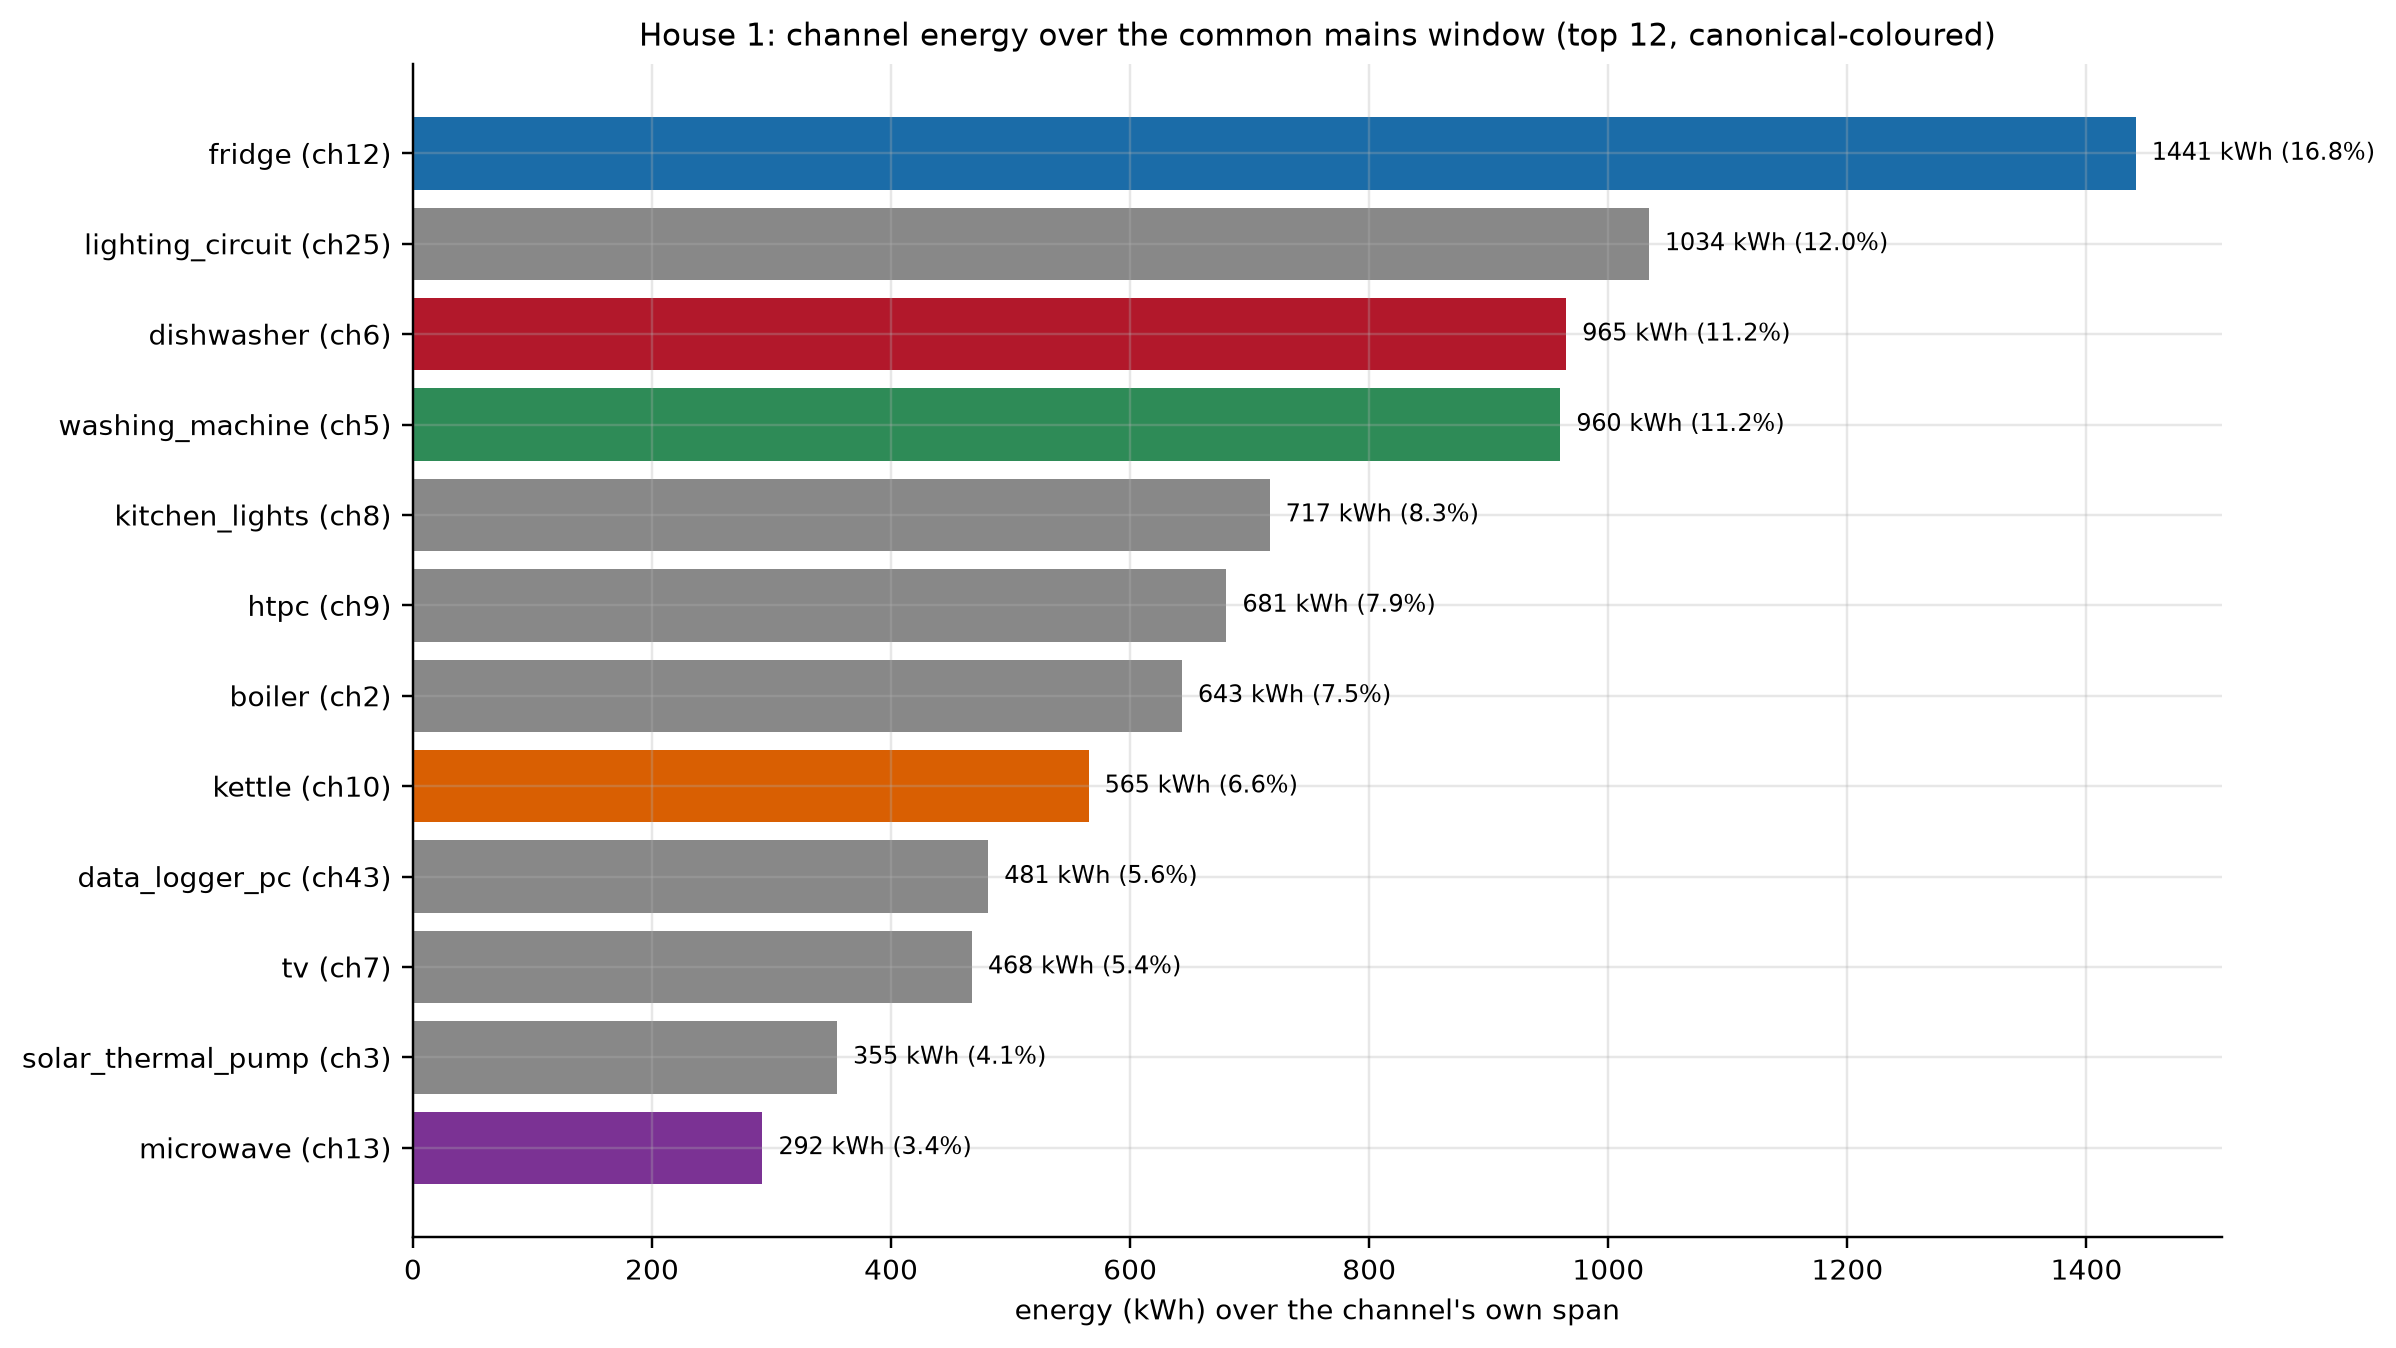

In [ ]:
items = [(r.label + ' (ch%d)' % int(r.ch), float(r.energy_kwh), eda.canon_color(r.label)) for r in cdf[cdf.ch != 1].head(12).itertuples()]
_fig, _ax = plt.subplots(figsize=(11, 0.4 * len(items) + 1.4))
eda.fig_energy_share(items, ax=_ax, title='House 1: channel energy over the common mains window (top 12, canonical-coloured)')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The fridge is the single biggest labelled consumer (≈1,440 kWh over the mains window), with the dishwasher (≈965) and washing machine (≈960) in a near tie behind it. The next tier is *not* appliance-shaped: lighting (two channels together ≈1,750 kWh), an always-on home-theatre PC (≈680), the boiler circuit (≈640). The five canonical targets account for **34%** of the whole home's energy (their ≈4,220 kWh over the site meter's 12,268); lights and electronics form the next tranche; the rest is a long tail. Note the table's top row: channel 1, the 6-second "aggregate", integrates ≈13,800 kWh — 13% more than the site meter over the same window (reconciled in Q7). Energy tells us what pays; episode counts tell us what is *recognisable* — both views matter.

## Q3 — How does each appliance behave?

*What does "ON" look like for each target — how often, how long, and when in the day?*

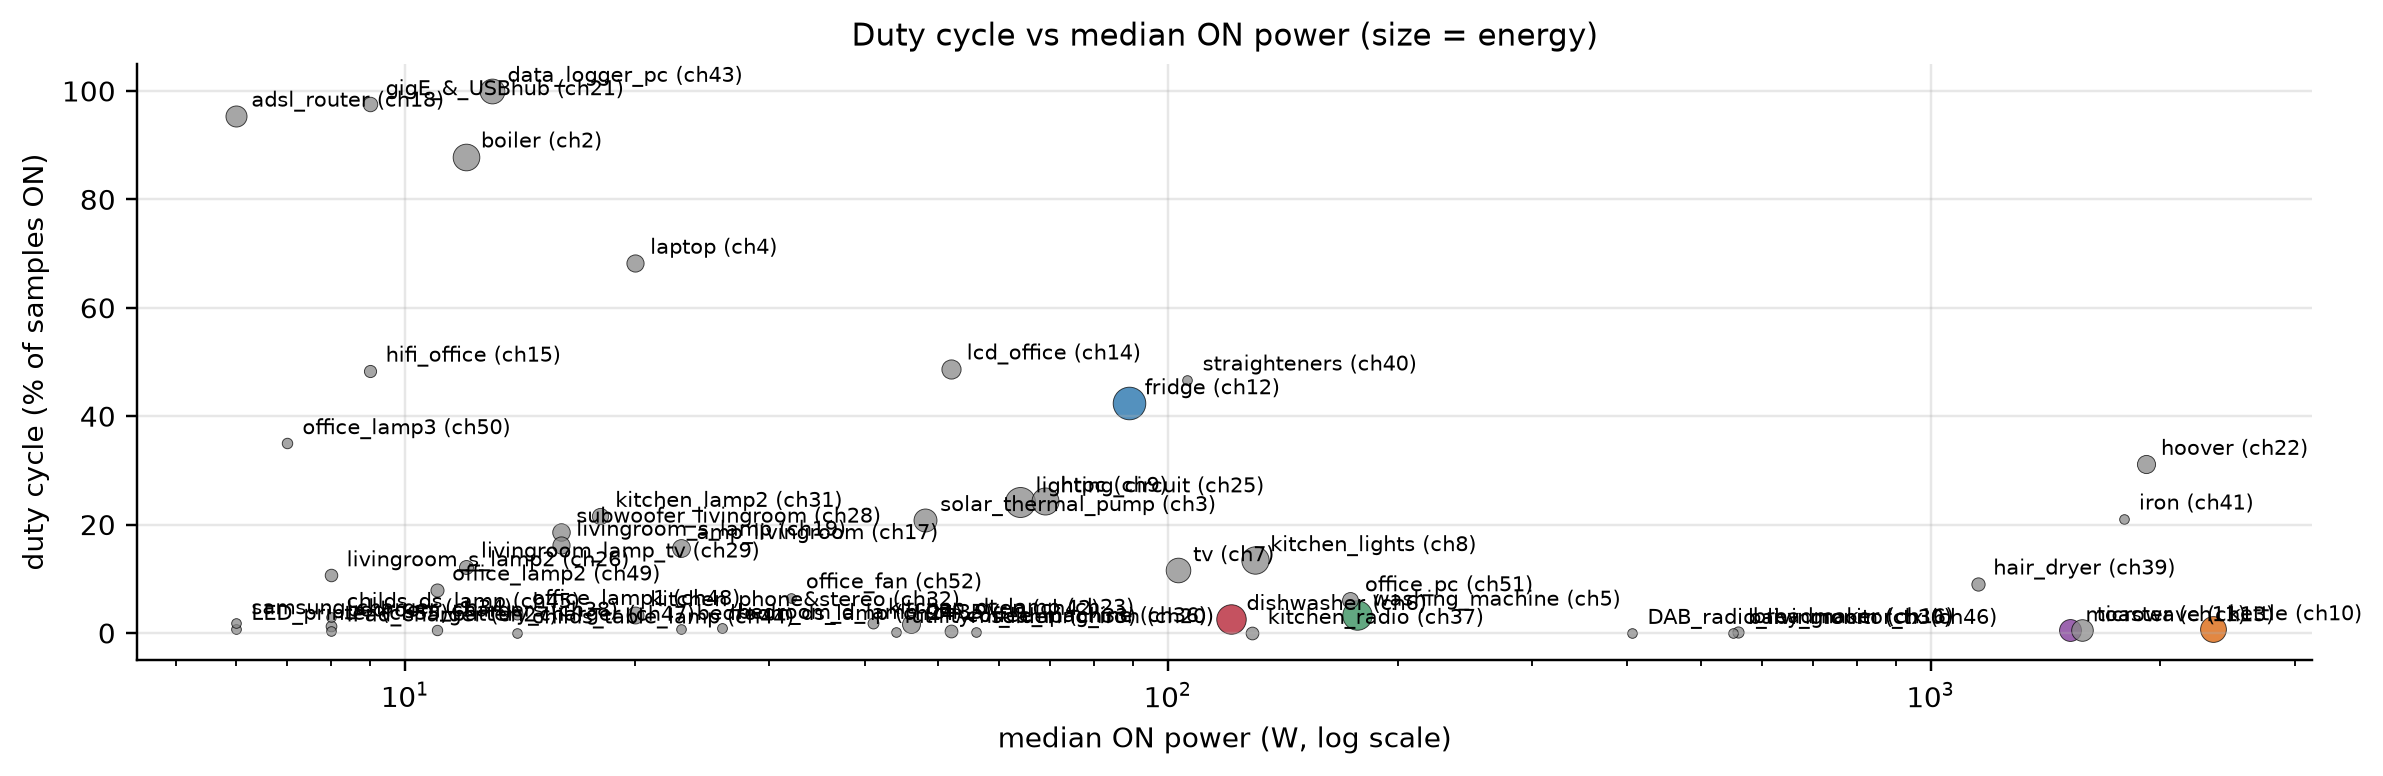

In [ ]:
rows_dv = []
for _r in cdf.itertuples():
    if _r.dwell_p50_s != _r.dwell_p50_s or int(_r.ch) == 1:
        continue
    rows_dv.append({'label': _r.label + ' (ch%d)' % int(_r.ch), 'duty': float(_r.on_share), 'p50_on_w': float(_r.p50_on_w), 'energy_kwh': float(_r.energy_kwh), 'color': eda.canon_color(_r.label)})
_fig, _ax = plt.subplots(figsize=(11, 3.6))
eda.fig_duty_vs_power(rows_dv, ax=_ax, title='Duty cycle vs median ON power (size = energy)')
_fig.tight_layout()
_fig  # render figure as cell output

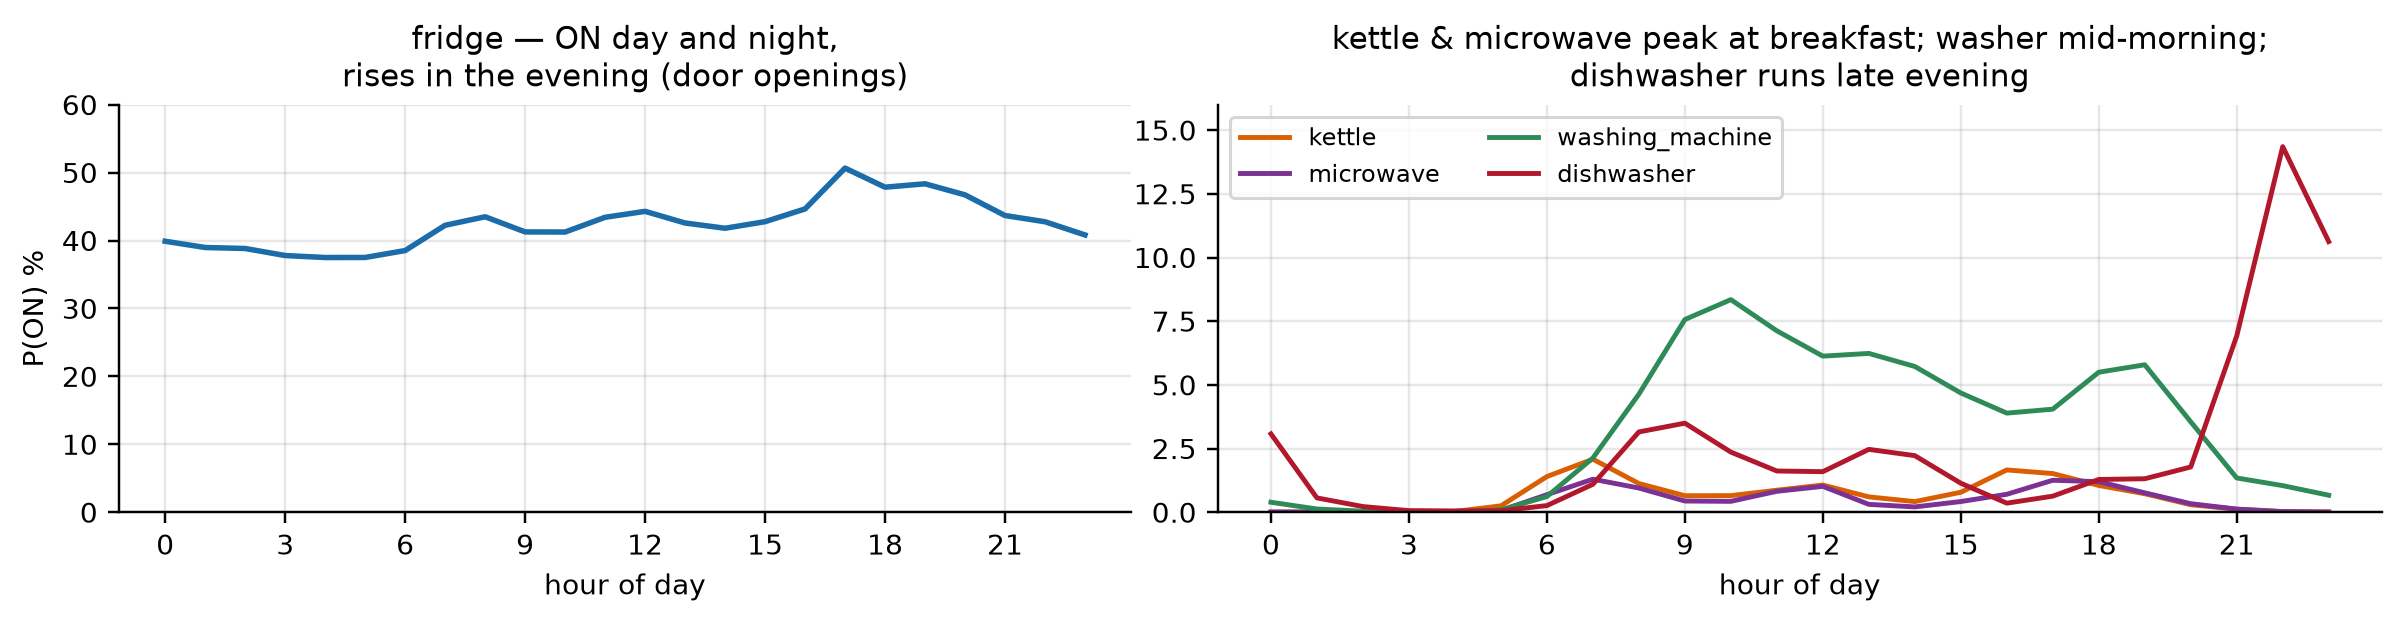

In [ ]:
def hourly_on(ch):
    tsc, vc, stc = ch_store[ch]
    on = np.asarray(vc) > float(stc['thr_on_w'])
    dts = np.diff(np.concatenate([tsc, [tsc[-1] + int(float(stc['dt_med_s']) * 1000000.0)]])).astype(np.float64)
    dtc = np.minimum(dts, 10 * float(stc['dt_med_s']) * 1000000.0)
    hr = np.asarray(tsc) // 3600000000 % 24
    pon = np.bincount(hr, weights=np.where(on, dtc, 0.0), minlength=24)
    pall = np.bincount(hr, weights=dtc, minlength=24)
    return 100 * pon / np.maximum(pall, 1e-09)
hp = {r.label: hourly_on(int(r.ch)) for r in canon_rows.itertuples()}
_fig, _ax = plt.subplots(1, 2, figsize=(11, 2.9), gridspec_kw={'width_ratios': [1, 1.15]})
_ax[0].plot(range(24), hp['fridge'], lw=1.8, color=eda.CANON_COLORS['fridge'])
_ax[0].set_ylim(0, 60)
_ax[0].set_title('fridge — ON day and night,\nrises in the evening (door openings)')
_ax[0].set_ylabel('P(ON) %')
_ax[0].set_xlabel('hour of day')
_ax[1].axhline(0, color='#cccccc', lw=0.6)
for cname in ['kettle', 'microwave', 'washing_machine', 'dishwasher']:
    _ax[1].plot(range(24), hp[cname], lw=1.6, color=eda.CANON_COLORS[cname], label=cname)
_ax[1].set_ylim(0, 16)
_ax[1].set_title('kettle & microwave peak at breakfast; washer mid-morning;\ndishwasher runs late evening')
_ax[1].set_xlabel('hour of day')
_ax[1].legend(fontsize=8, ncol=2, loc='upper left')
for _a in _ax:
    _a.set_xticks(range(0, 24, 3))
_fig.tight_layout()
_fig  # render figure as cell output

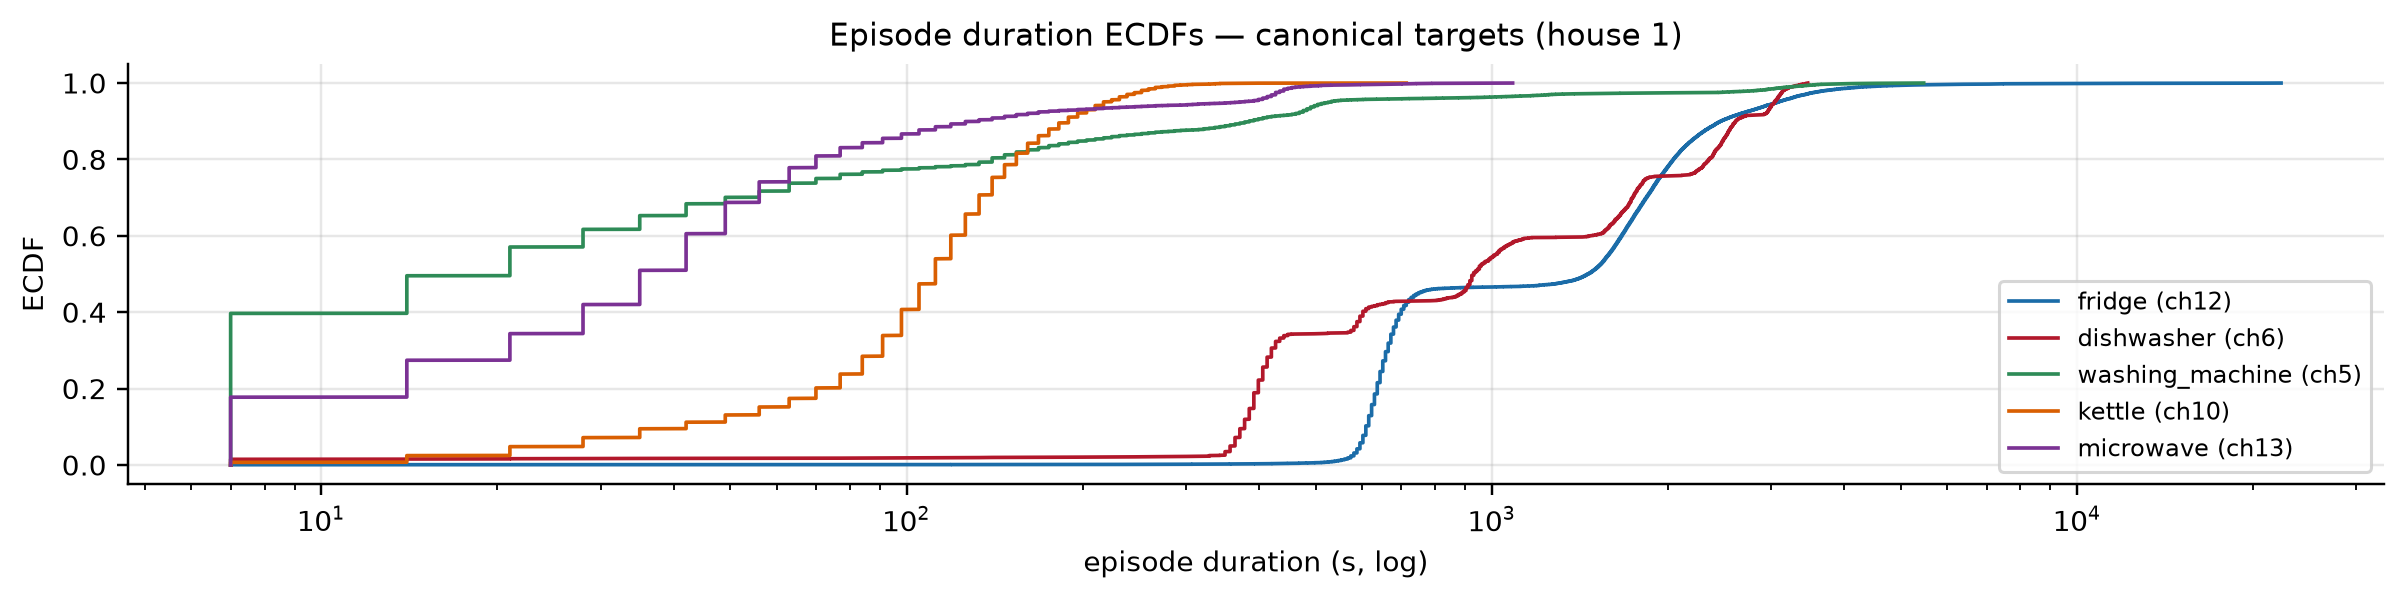

In [ ]:
_fig, _ax = plt.subplots(figsize=(11, 2.8))
eda.fig_dwell_ecdf([(r.label + ' (ch%d)' % int(r.ch), np.asarray(r.dwell_array), eda.canon_color(r.label)) for r in canon_rows.itertuples()], ax=_ax, title='Episode duration ECDFs — canonical targets (house 1)')
_fig.tight_layout()
_fig  # render figure as cell output

### How big is the step when a device switches on?

Episode counts say how often; the *step* the aggregate sees at each onset is what a disaggregator must detect. For every rising transition of at least 30 W (transitions spanning a sampling gap are dropped) of the canonicals plus two contrast appliances:

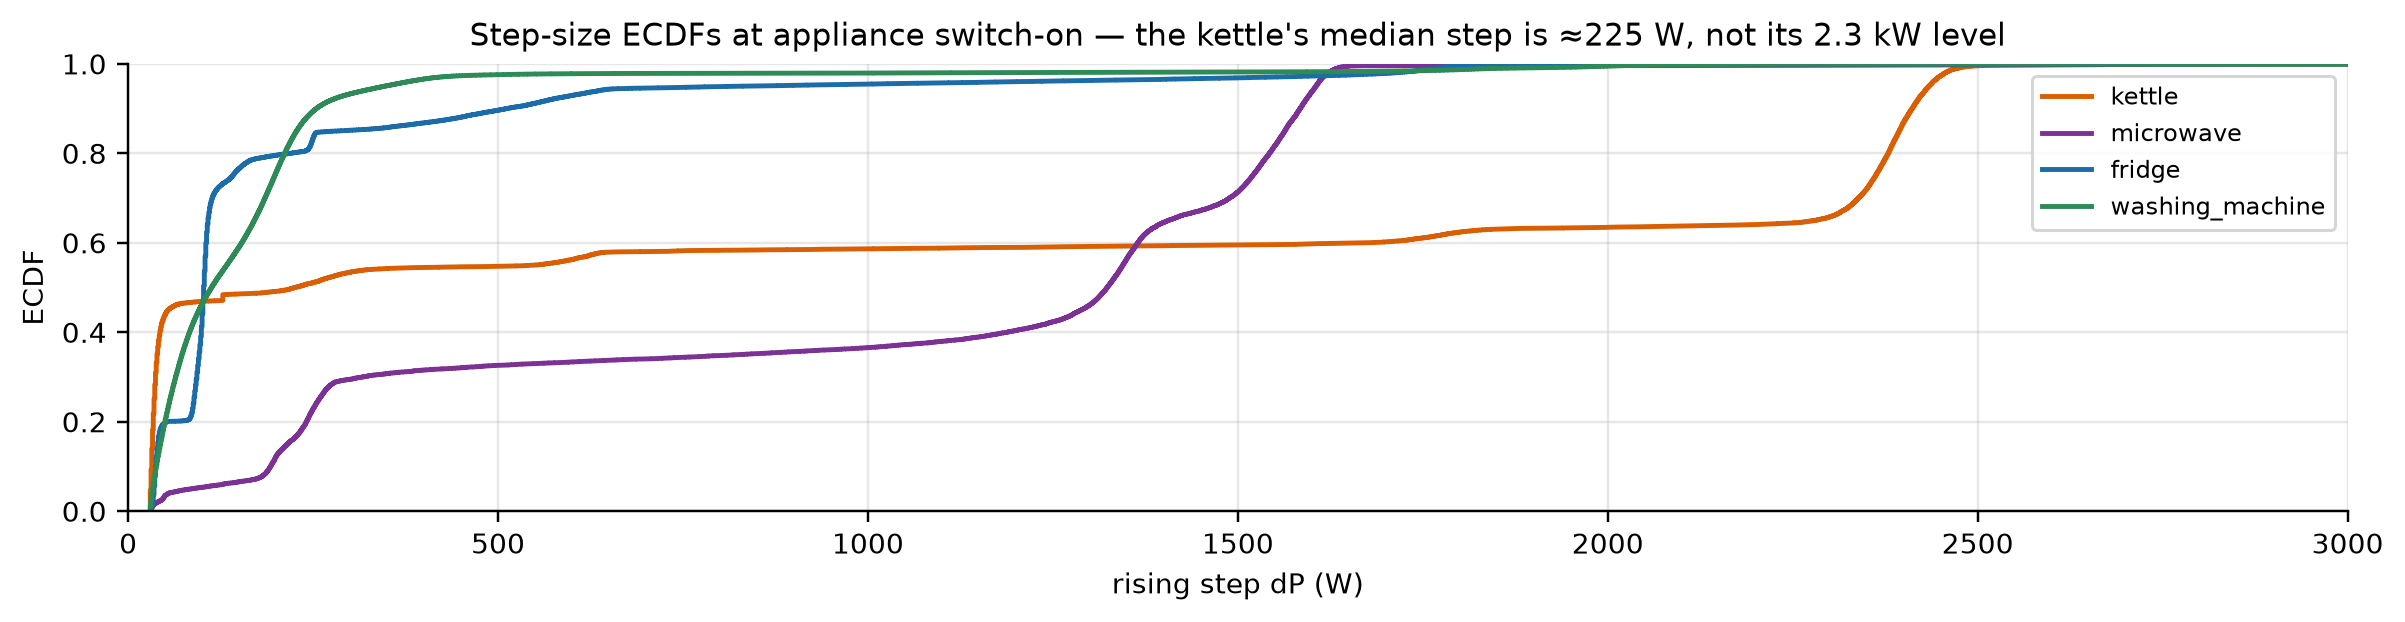

In [ ]:
dp_chs = [(r.label, int(r.ch)) for r in canon_rows.itertuples()] + [('iron', 41), ('toaster', 11)]
dp_rows = []
for _lab, _ch in dp_chs:
    _tsc, _vc, _stc = ch_store[_ch]
    steps_c = eda.onset_steps(np.asarray(_tsc), np.asarray(_vc), missing_values=(), min_step_w=30.0, gap_tol_s=3 * float(_stc['dt_med_s']))
    if len(steps_c) < 20:
        continue
    dp_rows.append([_lab, int(_ch), round(float(_stc['p50_on_w'])), len(steps_c), round(float(np.median(steps_c))), round(float(np.percentile(steps_c, 90)))])
dp_rows.sort(key=lambda r: -r[4])
_fig, _ax = plt.subplots(figsize=(11, 2.9))
for _lab, col in (('kettle', 'kettle'), ('microwave', 'microwave'), ('fridge', 'fridge'), ('washing_machine', 'washing_machine')):
    _ch = dict(dp_chs)[_lab]
    _tsc, _vc, _stc = ch_store[_ch]
    steps_c = np.sort(eda.onset_steps(np.asarray(_tsc), np.asarray(_vc), missing_values=(), min_step_w=30.0, gap_tol_s=3 * float(_stc['dt_med_s'])))
    _ax.plot(steps_c, np.linspace(0, 1, len(steps_c)), lw=1.6, label=_lab, color=eda.CANON_COLORS[col])
_ax.set_xlim(0, 3000)
_ax.set_ylim(0, 1)
_ax.set_xlabel('rising step dP (W)')
_ax.set_ylabel('ECDF')
_ax.legend(fontsize=8)
_ax.set_title("Step-size ECDFs at appliance switch-on — the kettle's median step is ≈225 W, not its 2.3 kW level")
_fig.tight_layout()
mo.md(eda.md_table(['appliance', 'ch', 'median ON W', 'n steps', 'dP p50 W', 'dP p90 W'], dp_rows))
_fig  # render figure as cell output

**Reading it.** The kettle draws 2.3 kW at its median ON level (Q2), yet its **median rising step is only ≈225 W** (p90 ≈2.4 kW): the thermostat cycles the element, so a boil arrives as a burst of moderate steps with occasional full-size ones — roughly 2.7 qualifying steps per boil. The iron is the opposite: a clean ≈1.8 kW step every time (p50 1,778 / p90 1,823). The fridge steps in ≈100 W compressor increments. For the target deployment this is the difference between threshold logic that works (iron) and one that silently misses (kettle) — step size is a property of the appliance, not of the meter.

### What does the raw trace of each device look like?

Summaries are compact, but the raw trace is what a disaggregation model actually has to recognise.
One representative window per device - for the burst appliances (kettle, microwave, fridge) the
episode closest to the median duration; for the washer the longest episode (its median "episode" is a
14-second control draw); padded for context, with each device's ON threshold drawn dashed.

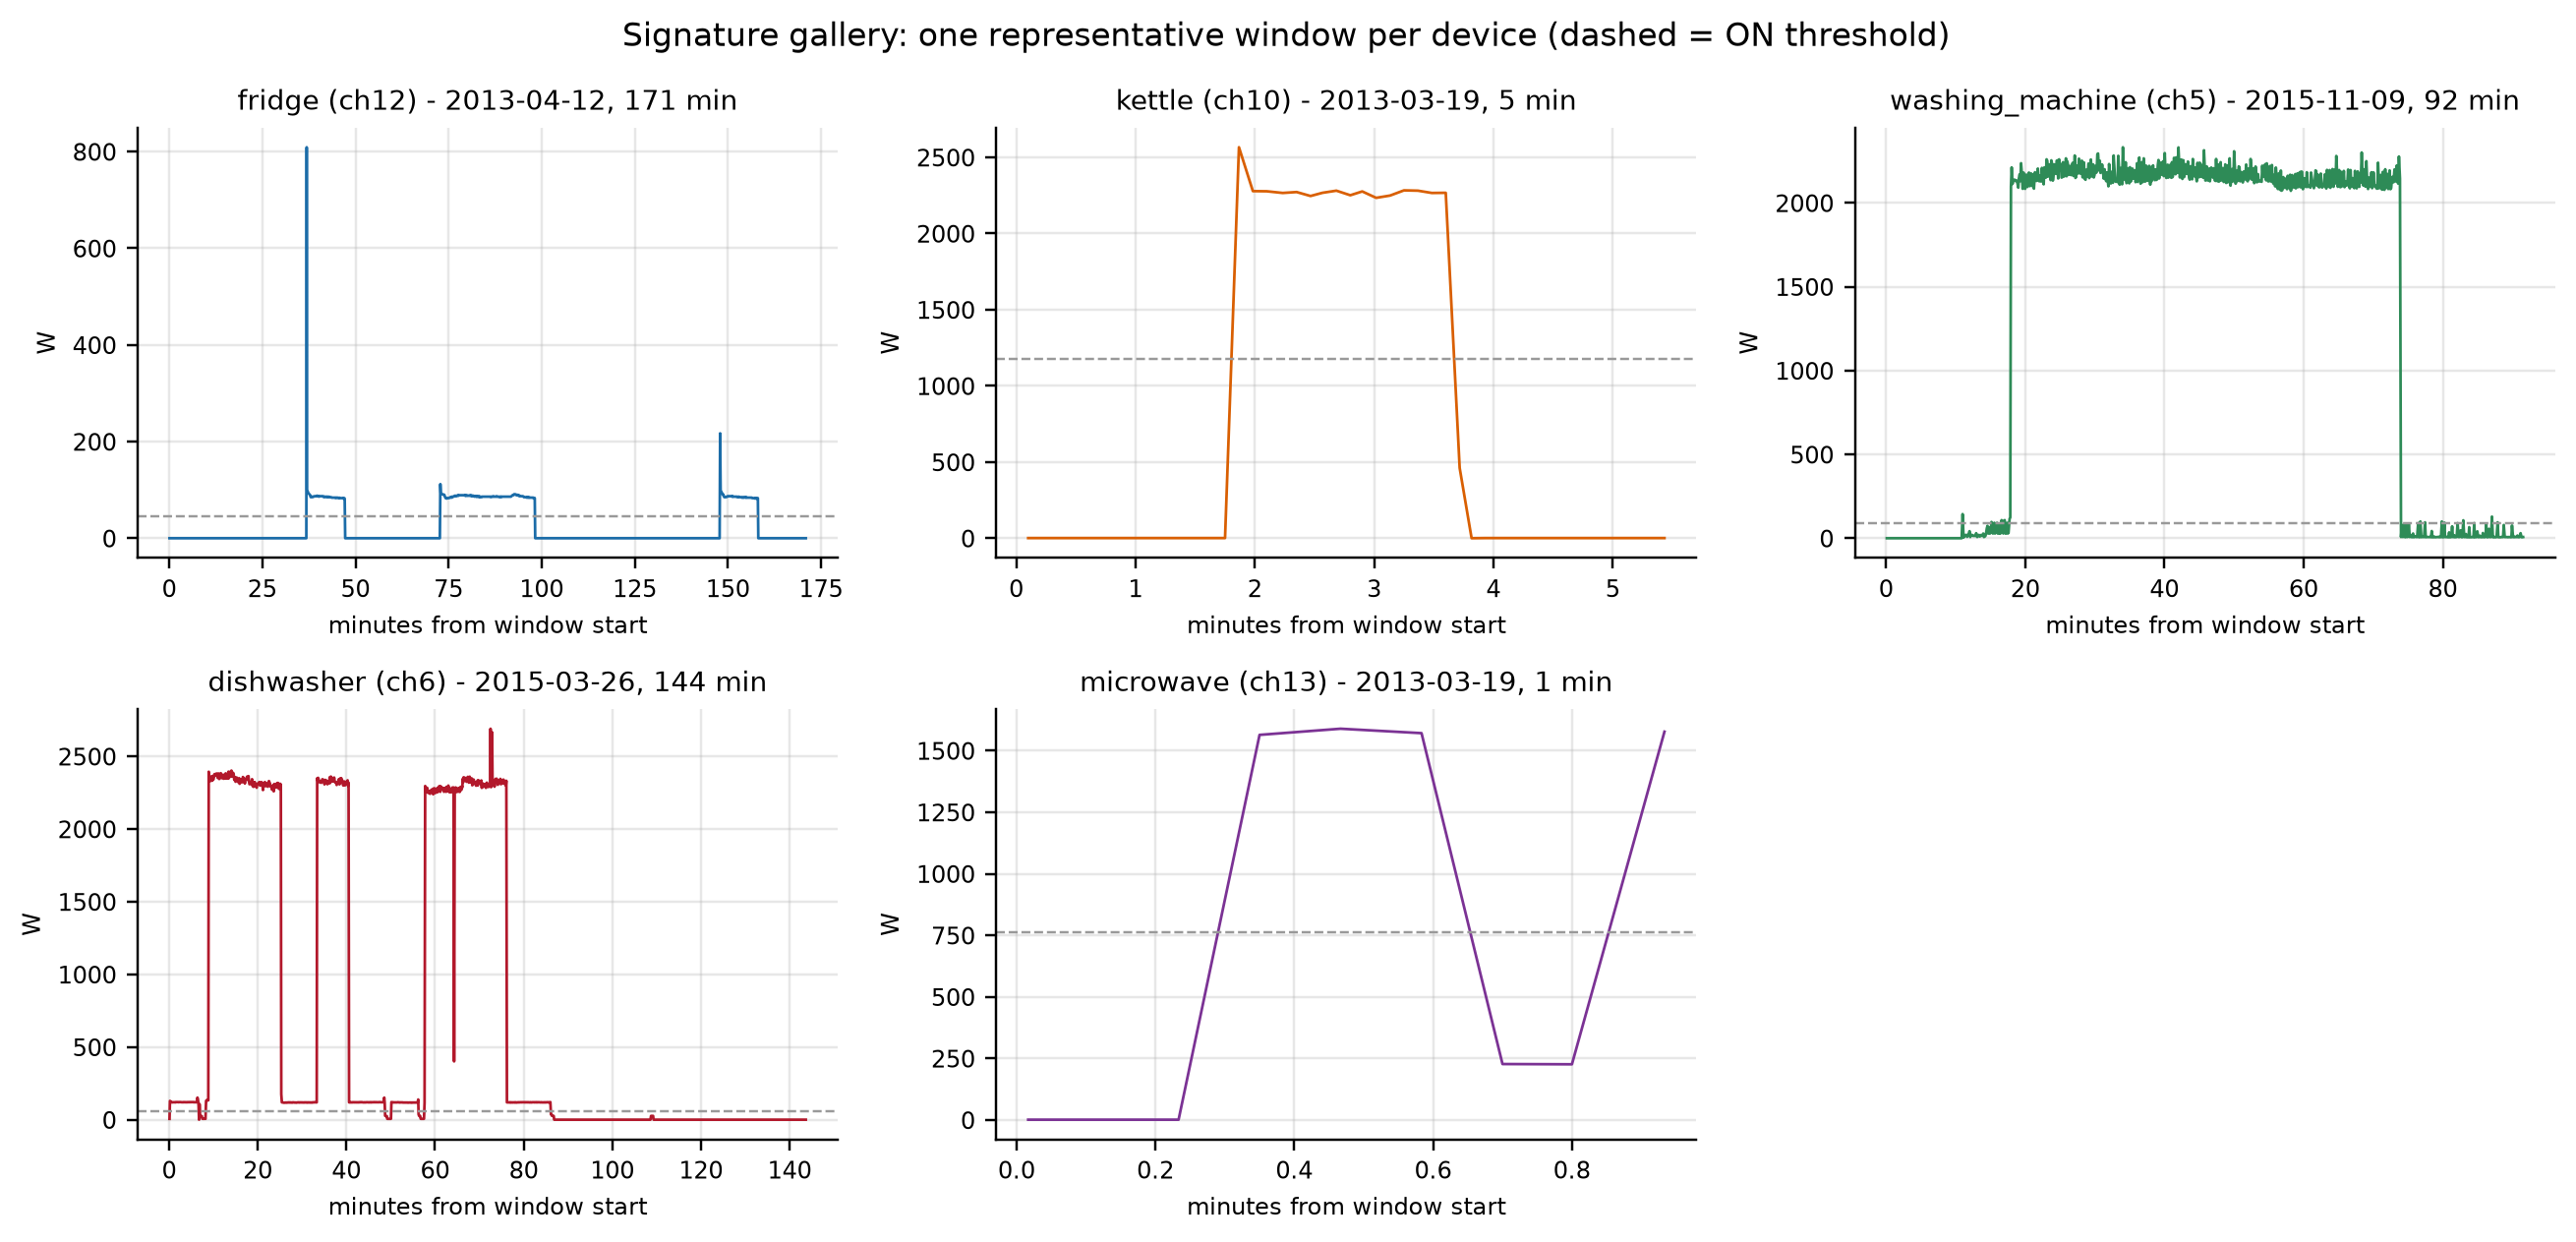

In [ ]:
sig_defs = [('fridge', 12, 50, 3.0, 180), ('kettle', 10, 50, 1.0, 30), ('washing_machine', 5, 100, 0.3, 360), ('dishwasher', 6, 75, 2.0, 360), ('microwave', 13, 50, 1.0, 30)]  # label, channel, dwell percentile to target, pad multiplier, window cap (min)
_fig, axes = plt.subplots(2, 3, figsize=(12, 5.8))
for _ax, (_lab, _ch, pct, pad_m, cap_min) in zip(axes.ravel(), sig_defs):
    _tsc, _vc, _stc = ch_store[_ch]
    _thr = float(_stc['thr_on_w'])
    dtm = float(_stc['dt_med_s'])
    on = (np.asarray(_vc) > _thr).astype(np.int8)
    _d = np.diff(np.concatenate([[0], on, [0]]))
    starts, ends = (np.where(_d == 1)[0], np.where(_d == -1)[0])
    if len(starts) == 0:
        _ax.set_title(_lab + ': no ON episodes')
        continue
    dwl = (ends - starts) * dtm
    _i = int(np.argmin(np.abs(dwl - np.percentile(dwl, pct))))
    pad_us = min(float(dwl[_i]) * pad_m, cap_min * 60.0) * 1000000.0
    t0 = float(_tsc[starts[_i]]) - pad_us
    t1 = float(_tsc[ends[_i] - 1]) + pad_us
    msk = (np.asarray(_tsc) >= t0) & (np.asarray(_tsc) <= t1)
    xm = (np.asarray(_tsc)[msk] - t0) / 60000000.0
    _ax.plot(xm, np.asarray(_vc)[msk], lw=0.9, color=eda.canon_color(_lab))
    _ax.axhline(_thr, color='#999999', ls='--', lw=0.8)
    day = str(pd.to_datetime(t0, unit='us'))[:10]
    _ax.set_title('%s (ch%d) - %s, %.0f min' % (_lab, _ch, day, (t1 - t0) / 60000000.0), fontsize=9)
    _ax.set_xlabel('minutes from window start', fontsize=8)
    _ax.set_ylabel('W', fontsize=8)
    _ax.tick_params(labelsize=8)
for ax_h in axes.ravel()[len(sig_defs):]:
    ax_h.set_visible(False)
_fig.suptitle('Signature gallery: one representative window per device (dashed = ON threshold)')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The gallery makes the signatures concrete: the fridge's compressor sawtooth with a periodic defrost spike; the kettle's single clean trapezoid at 2.3 kW; a real washing-machine program - 2.2 kW of heater and motor for well over an hour, not the 14-second control draws that dominate its episode count; the dishwasher's three heater pulses spread across two hours; the microwave's one-minute trapezoid. Even at 6-second cadence these shapes are distinct - that is what a disaggregation model keys on. The two circuits that never really switch off - the lighting circuit and the boiler - get their own exhibit below.

The scatter then separates appliance *types*: fridge = low power (89 W median ON) / high duty (42%); kettle = 2.3 kW / ON 0.7% of the time; washer and dishwasher = mid power, rare but long. The hour-of-day curves are the household's schedule made visible (hours UTC; British Summer Time would shift them one hour later on the local clock): **kettle and microwave at 7–8 h (breakfast)**, **washing machine mid-morning (9–11 h)**, **dishwasher late evening (21–24 h, peaking at 14%)**, and the fridge on around the clock with an evening rise. Dwell ECDFs: kettle ≈2 min; dishwasher ≈16 min median, p90 ≈1 h. The washer's meter also catches **14-second control draws** (19.4 "episodes"/day) between real cycles — episode filtering needs a dwell floor.

### The long runners - lighting_circuit and the boiler - [insight only]

Not every circuit blinks on and off. Two house 1 circuits stay effectively ON for days: the lighting circuit and the boiler (its pump and controller cycling almost continuously). The gallery showed bounded signatures; these need the opposite treatment - zoom out to see the plateau, then zoom in to see the switch and the pump.

lighting longest ON: 7.8 days | boiler longest ON: 771 h


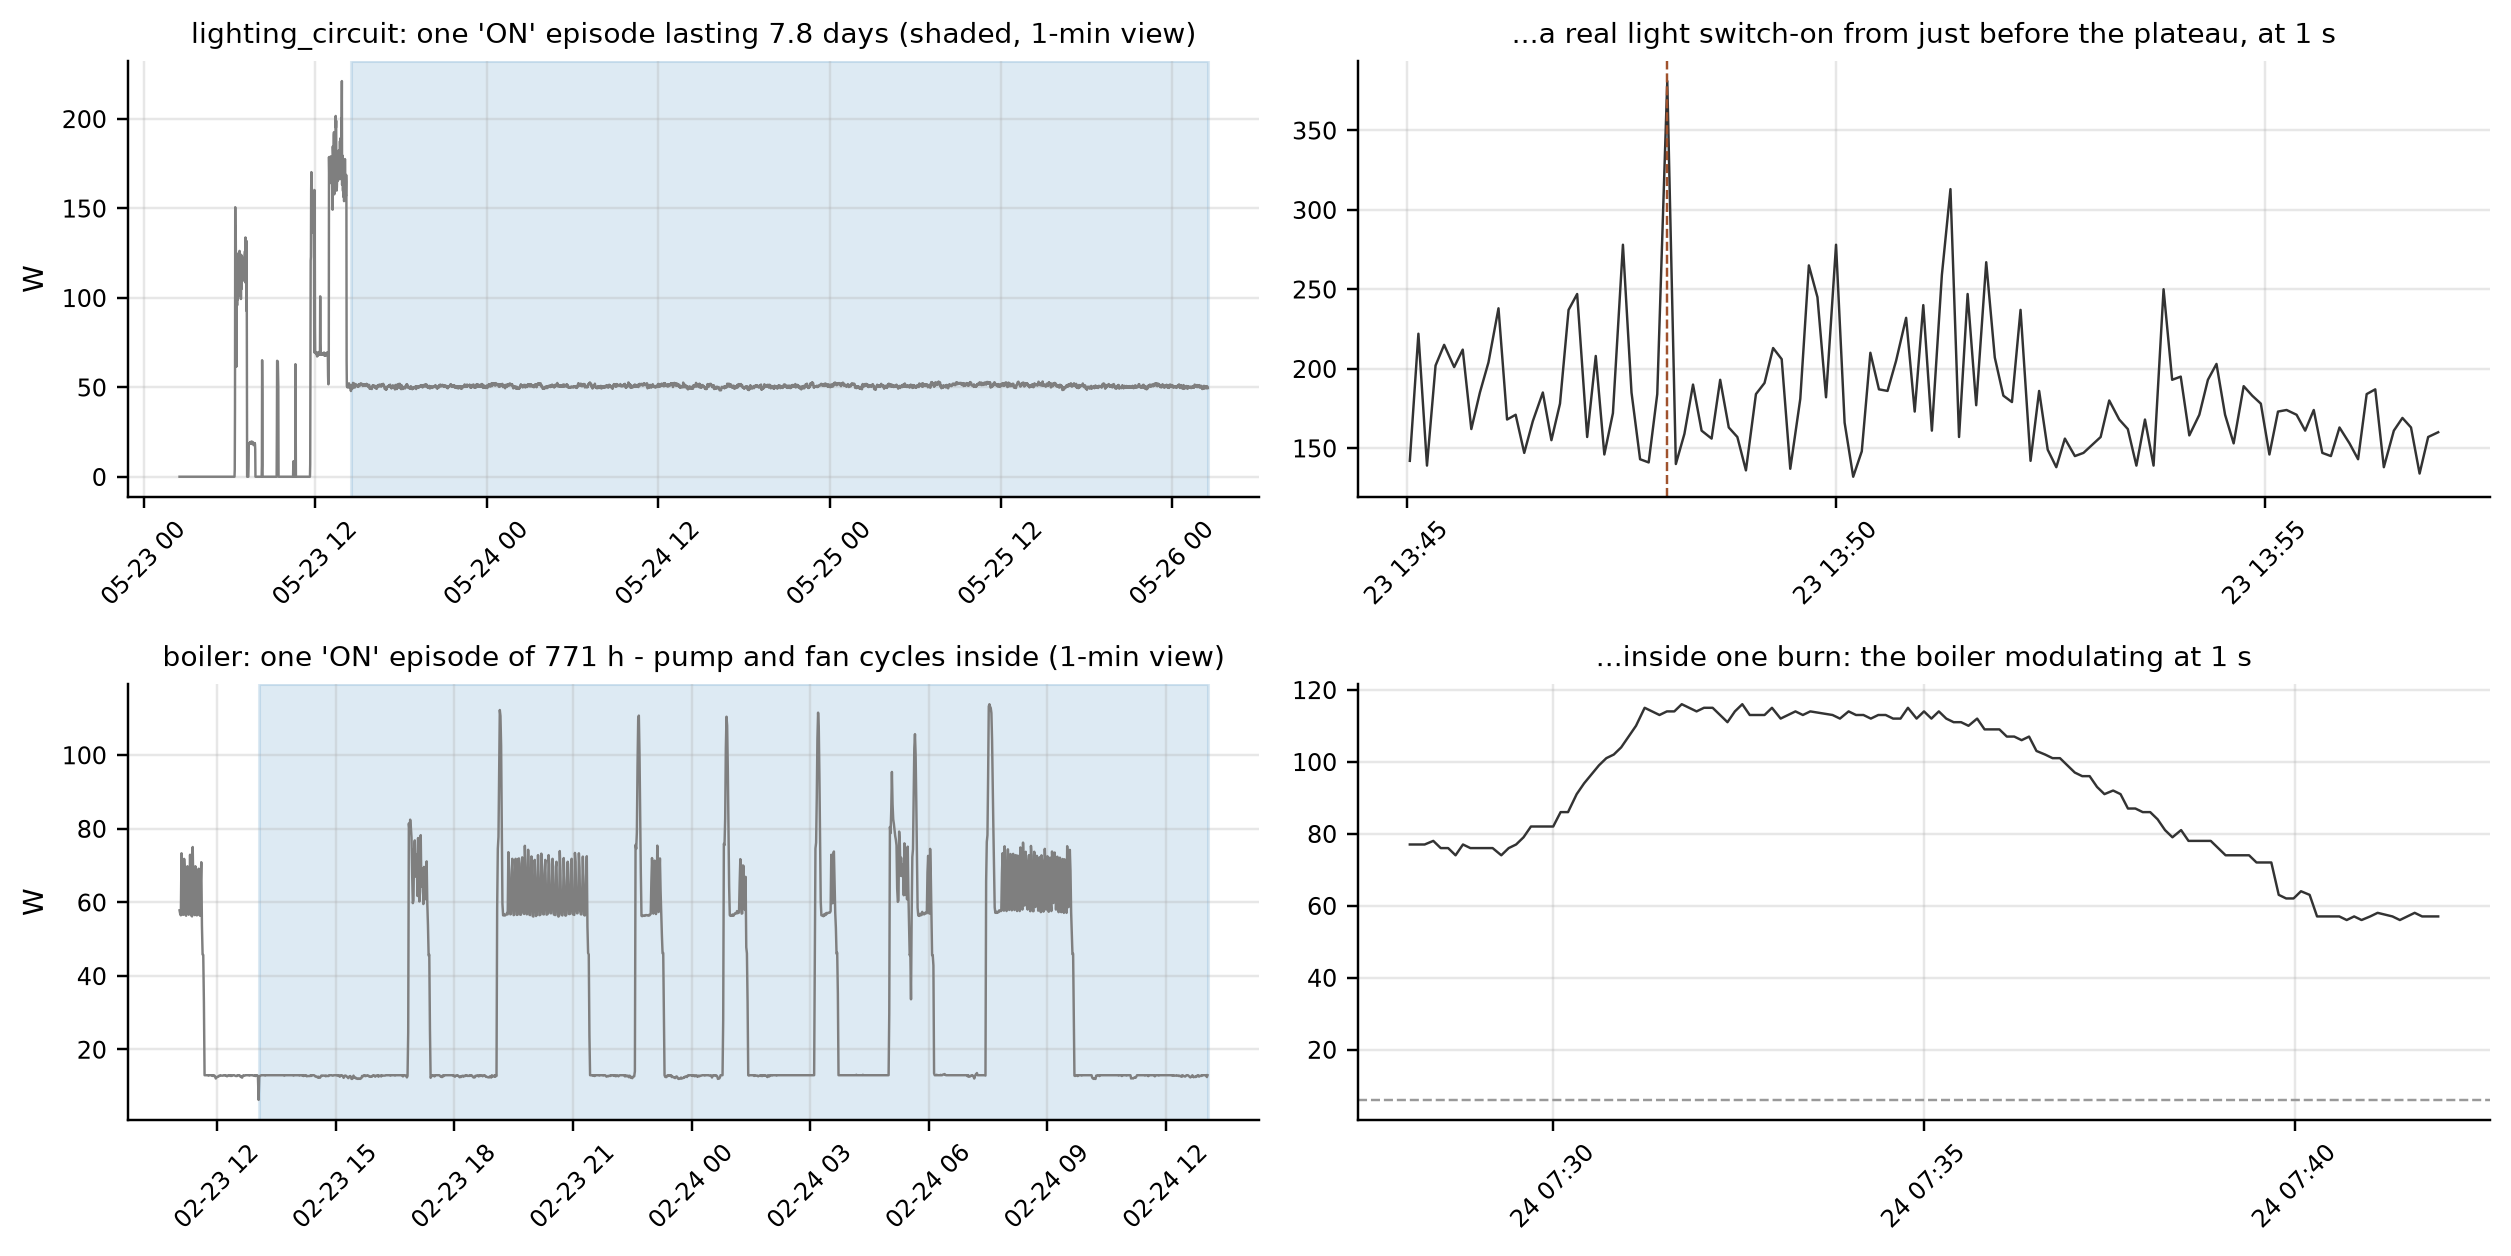

In [ ]:
_ts_l, v_l, st_l = ch_store[25]
thr_l, dtl = (float(st_l['thr_on_w']), float(st_l['dt_med_s']))
_on_l = (np.asarray(v_l) > thr_l).astype(np.int8)
d_l = np.diff(np.concatenate([[0], _on_l, [0]]))
st_s, en_s = (np.where(d_l == 1)[0], np.where(d_l == -1)[0])
i_lg = int(np.argmax(en_s - st_s))
dur_l_d = (en_s[i_lg] - st_s[i_lg]) * dtl / 86400.0
t_on_us, t_off_us = (float(_ts_l[st_s[i_lg]]), float(_ts_l[en_s[i_lg] - 1]))
msk_l = (np.asarray(_ts_l) >= t_on_us - 12 * 3600 * 1000000) & (np.asarray(_ts_l) <= min(t_off_us, t_on_us + 60 * 3600 * 1000000))
s_l = pd.Series(np.asarray(v_l)[msk_l], index=pd.to_datetime(np.asarray(_ts_l)[msk_l], unit='us')).resample('1min').mean()
ts_b, v_b, st_b = ch_store[2]
thr_b, dtb = (float(st_b['thr_on_w']), float(st_b['dt_med_s']))
on_b = (np.asarray(v_b) > thr_b).astype(np.int8)
d_b = np.diff(np.concatenate([[0], on_b, [0]]))
st_b2, en_b2 = (np.where(d_b == 1)[0], np.where(d_b == -1)[0])
i_bg = int(np.argmax(en_b2 - st_b2))
dur_b_h = (en_b2[i_bg] - st_b2[i_bg]) * dtb / 3600.0
t_onb_us, t_offb_us = (float(ts_b[st_b2[i_bg]]), float(ts_b[en_b2[i_bg] - 1]))
msk_b = (np.asarray(ts_b) >= t_onb_us - 2 * 3600 * 1000000) & (np.asarray(ts_b) <= min(t_offb_us, t_onb_us + 24 * 3600 * 1000000))
s_b = pd.Series(np.asarray(v_b)[msk_b], index=pd.to_datetime(np.asarray(ts_b)[msk_b], unit='us')).resample('1min').mean()
_fig, axg = plt.subplots(2, 2, figsize=(11.5, 5.8))
axg[0, 0].plot(s_l.index, s_l.values, lw=0.8, color='#7f7f7f')
axg[0, 0].axvspan(pd.to_datetime(t_on_us, unit='us'), pd.to_datetime(min(t_off_us, t_on_us + 60 * 3600 * 1000000), unit='us'), alpha=0.15, color='#1f77b4')
axg[0, 0].set_title("lighting_circuit: one 'ON' episode lasting %.1f days (shaded, 1-min view)" % dur_l_d, fontsize=9)
axg[0, 0].set_ylabel('W')
pre = (np.asarray(_ts_l) >= t_on_us - 12 * 3600 * 1000000) & (np.asarray(_ts_l) <= t_on_us)
i_pk = int(np.argmax(np.where(pre, np.asarray(v_l), -1.0)))
t_pk_l = float(np.asarray(_ts_l)[i_pk])
mz = (np.asarray(_ts_l) >= t_pk_l - 3 * 60000000) & (np.asarray(_ts_l) <= t_pk_l + 9 * 60000000)
axg[0, 1].plot(pd.to_datetime(np.asarray(_ts_l)[mz], unit='us'), np.asarray(v_l)[mz], lw=0.8, color='#333333')
axg[0, 1].axvline(pd.to_datetime(t_pk_l, unit='us'), color='#a0522d', lw=0.8, ls='--')
axg[0, 1].set_title('...a real light switch-on from just before the plateau, at 1 s', fontsize=9)
axg[1, 0].plot(s_b.index, s_b.values, lw=0.8, color='#7f7f7f')
axg[1, 0].axvspan(pd.to_datetime(t_onb_us, unit='us'), pd.to_datetime(min(t_offb_us, t_onb_us + 24 * 3600 * 1000000), unit='us'), alpha=0.15, color='#1f77b4')
axg[1, 0].set_title("boiler: one 'ON' episode of %.0f h - pump and fan cycles inside (1-min view)" % dur_b_h, fontsize=9)
axg[1, 0].set_ylabel('W')
if s_b.notna().any():
    t_pk_us = int(s_b.idxmax().value // 1000)
    mz2 = (np.asarray(ts_b) >= t_pk_us - 4 * 60000000) & (np.asarray(ts_b) <= t_pk_us + 10 * 60000000)
    axg[1, 1].plot(pd.to_datetime(np.asarray(ts_b)[mz2], unit='us'), np.asarray(v_b)[mz2], lw=0.8, color='#333333')
    axg[1, 1].axhline(thr_b, color='#999999', ls='--', lw=0.8)
axg[1, 1].set_title('...inside one burn: the boiler modulating at 1 s', fontsize=9)
for _a in axg.ravel():
    _a.tick_params(axis='x', rotation=45, labelsize=8)
    _a.tick_params(axis='y', labelsize=8)
_fig.tight_layout()
print('lighting longest ON: %.1f days | boiler longest ON: %.0f h' % (dur_l_d, dur_b_h))
_fig  # render figure as cell output

**Reading it [insight only].** 'Appliance off = 0 W' is a fiction. The lighting circuit's longest 'ON' episode is a flat ~50 W plateau held for 7.8 days - an always-on device riding on the lighting circuit, not lights; real light switching (right panel) is a bursty step on top of such baselines. The boiler circuit idles at ~14 W and burns in smooth 60-115 W modulations, hundreds of times over a multi-week stretch - invisible individually in a daily mean, collectively most of its 664 kWh. Baselines are made of circuits like these; a model that only hunts big square pulses will miss them.

## Q4 — Is the fridge stable across 4 years?

*The fridge is the always-there anchor a model sees every day — does its behaviour drift?*

Weekly duty cycle over the whole span:

fridge weekly duty: mean 42.4% | p5 35.0% | p95 49.6% | weeks 215
defrost-band (200-300 W) share of fridge ON time: 2.9% - a third state between compressor and OFF


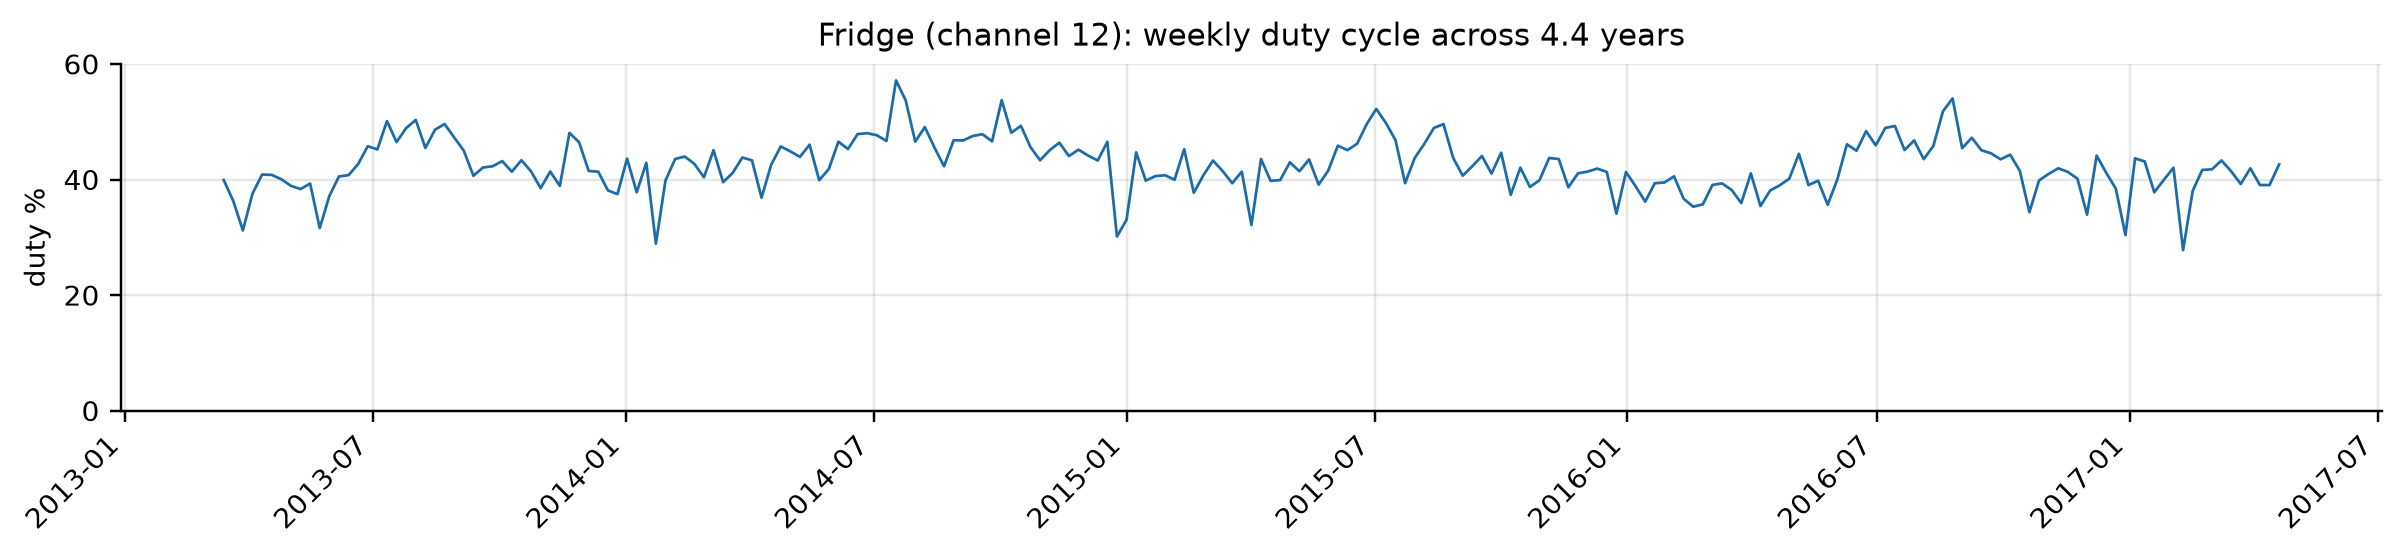

In [ ]:
ts_f, v_f, st_f = ch_store[12]
on_f = np.asarray(v_f) > float(st_f['thr_on_w'])
dt_f = np.minimum(np.diff(np.concatenate([ts_f, [ts_f[-1] + int(float(st_f['dt_med_s']) * 1000000.0)]])).astype(np.float64), 10 * float(st_f['dt_med_s']) * 1000000.0)
wk = np.asarray(ts_f) // (7 * 86400 * 1000000)
uw, invw = np.unique(wk, return_inverse=True)
duty_w = 100 * np.bincount(invw, weights=np.where(on_f, dt_f, 0.0)) / np.maximum(np.bincount(invw, weights=dt_f), 1e-09)
_fig, _ax = plt.subplots(figsize=(11, 2.6))
_ax.plot((uw * 7).astype('datetime64[D]'), duty_w, lw=0.9, color=eda.CANON_COLORS['fridge'])
_ax.set_ylabel('duty %')
_ax.set_ylim(0, max(60, 1.05 * float(np.nanmax(duty_w))))
_ax.set_title('Fridge (channel 12): weekly duty cycle across 4.4 years')
_fig.autofmt_xdate(rotation=45)
_fig.tight_layout()
print('fridge weekly duty: mean %.1f%% | p5 %.1f%% | p95 %.1f%% | weeks %d' % (np.nanmean(duty_w), np.nanpercentile(duty_w, 5), np.nanpercentile(duty_w, 95), len(uw)))
defrost_share = 100 * float(np.mean(on_f & (np.asarray(v_f) > 200) & (np.asarray(v_f) < 300))) / float(np.mean(on_f))
print('defrost-band (200-300 W) share of fridge ON time: %.1f%% - a third state between compressor and OFF' % defrost_share)
_fig  # render figure as cell output

**Answer: yes — stationary.** Duty wobbles inside a 35–50% band (mean 42.4%) with no upward or downward trend across 215 weeks: the signature learned in year 1 still holds in year 4. Brief dips to ~30% recover within a week or two. One wrinkle the duty number hides: the compressor is not two-state — **2.9% of ON time sits in a 200-300 W defrost band** between the ~89 W compressor level and OFF (printed above), a third state a two-state model will systematically misread. This is the best-case appliance for signature learning.

## Q5 — Is household consumption seasonal?

*4.1 years is long enough to ask whether the house itself changes with the seasons.*

Energy per calendar month (from the same streaming pass as Q1), with the two data-hole months marked:

winter (Nov/Dec/Jan) mean 279 kWh | summer (Jun/Jul) mean 208 kWh | ratio 1.34


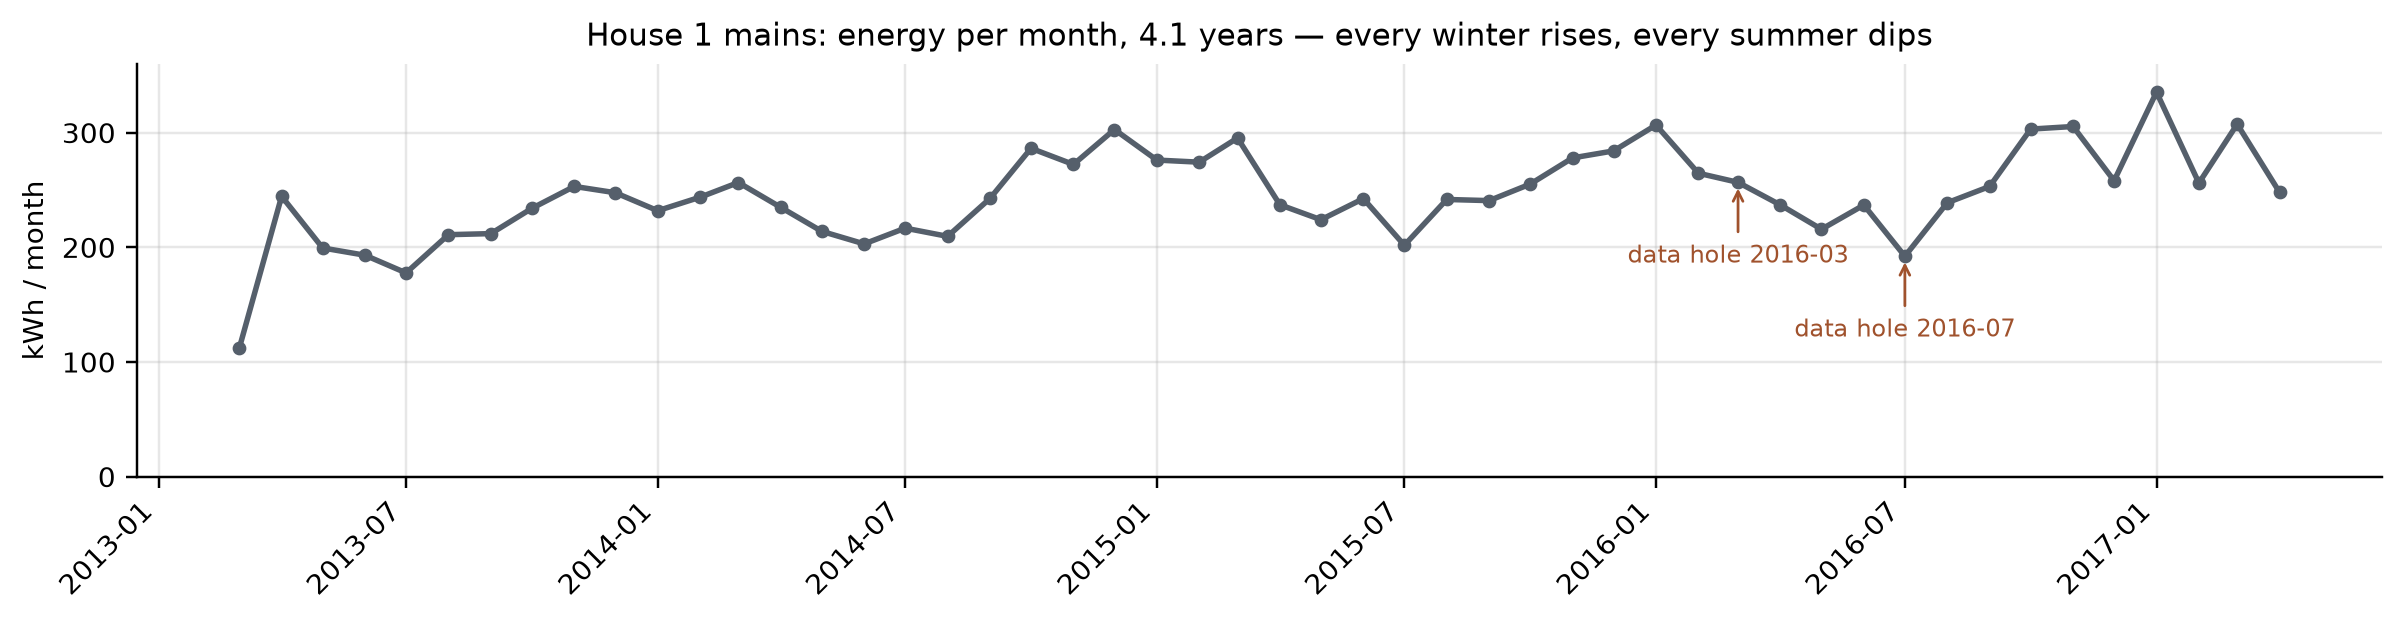

In [ ]:
hole_rank = {}
for g, t in gaps:
    if g > 6 * 3600000000.0:
        hm = str(pd.to_datetime(t, unit='us'))[:7]
        hole_rank[hm] = max(hole_rank.get(hm, 0), g)
hole_months = [hm for hm, _ in sorted(hole_rank.items(), key=lambda kv: -kv[1])]
ym = [m for m, _ in monthly_kwh]
kwh_m = [k for _, k in monthly_kwh]
_fig, _ax = plt.subplots(figsize=(11, 2.9))
_ax.plot(ym, kwh_m, lw=1.8, marker='o', ms=3.5, color='#555f6b')
_ax.set_ylim(0, 360)
_ax.set_ylabel('kWh / month')
_ax.set_title('House 1 mains: energy per month, 4.1 years — every winter rises, every summer dips')
for hmv in hole_months[:2]:
    _i = next((i for i, m in enumerate(ym) if str(m)[:7] == hmv))
    _ax.annotate('data hole ' + hmv, (ym[_i], kwh_m[_i]), xytext=(ym[_i], max(40, kwh_m[_i] - 70)), fontsize=8, ha='center', color='#a0522d', arrowprops=dict(arrowstyle='->', color='#a0522d', lw=0.9))
_fig.autofmt_xdate(rotation=45)
_fig.tight_layout()
inner = monthly_kwh[1:-1]
winter = [k for m, k in inner if pd.to_datetime(m).month in (11, 12, 1)]
summer = [k for m, k in inner if pd.to_datetime(m).month in (6, 7)]
season_ratio = float(np.mean(winter) / np.mean(summer))
print('winter (Nov/Dec/Jan) mean %.0f kWh | summer (Jun/Jul) mean %.0f kWh | ratio %.2f' % (np.mean(winter), np.mean(summer), season_ratio))
_fig  # render figure as cell output

**Answer: mildly but repeatably seasonal.** Every winter rises to ~250–335 kWh/month, every summer dips to ~180–240 — winter is ≈1.35× summer (279 vs 208 kWh on average), and the pattern repeats all five years. The two visible outlier dips (Mar 2016, Jul 2016) are the **data holes from Q1**, not behaviour — which is why Q1 comes first. Consequence: train/test splits that span seasons will see different baselines.

## Q6 — Do appliances run together?

*How much do the five canonical targets overlap?* If they never overlapped, disaggregation would be trivial arithmetic.

share of 60 s buckets with 2+ ON: 3.2%


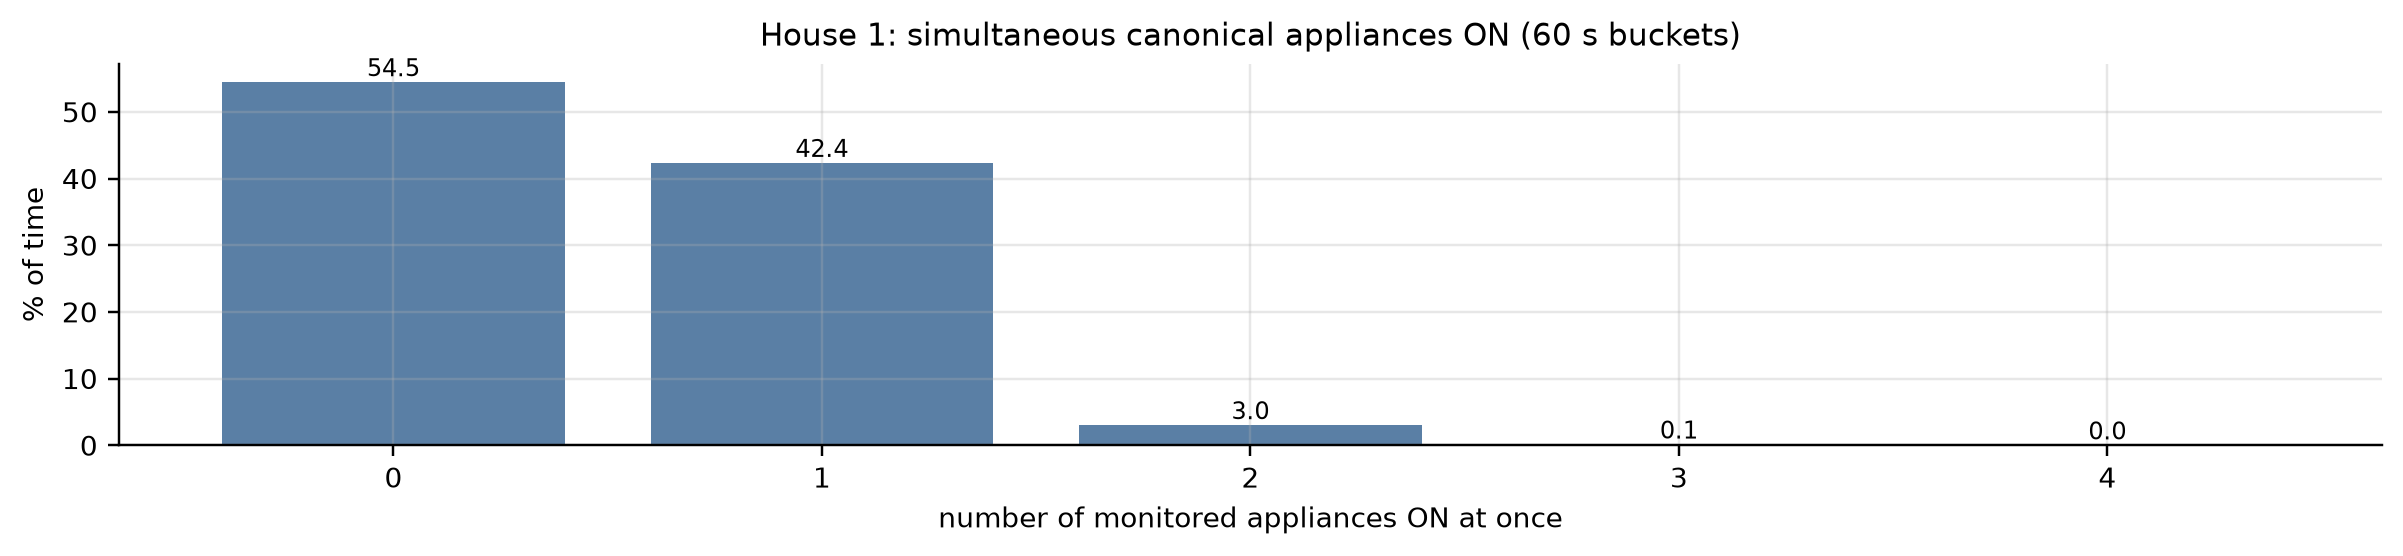

In [ ]:
_ts_l, _on_l = ([], [])
for _r in canon_rows.itertuples():
    _ts, _v, _ = ch_store[int(_r.ch)]
    _ts_l.append(_ts)
    _on_l.append((_v > _r.thr_on_w).astype(np.int8))
sim = eda.simultaneity(_ts_l, _on_l, bucket_s=60)
_fig, _ax = plt.subplots(figsize=(11, 2.6))
eda.fig_simultaneity(sim, ax=_ax, title='House 1: simultaneous canonical appliances ON (60 s buckets)')
_fig.tight_layout()
print('share of 60 s buckets with 2+ ON: %.1f%%' % (100 * sim['two_plus']))
_fig  # render figure as cell output

**Reading it.** **3.2% of 60-second buckets** have two or more canonical appliances ON. A small number with a big consequence: the fridge alone is ON 42% of the time, so almost every kettle boil or wash cycle happens *on top of* a compressor cycle. The mains is a **superposition**, not a sum of disjoint events — disaggregation has to un-mix, not partition.

### Event view: when a device starts, what else is already running?

The bucket view counts *time*. Disaggregation errors happen at *events* — so for every canonical episode of at least 30 s, we check which other canonicals were ON at its midpoint (nearest sample within 45 s):

In [ ]:
MIN_EP_S = 30.0
ev_rows = []
ev_pct = {}
for _r in canon_rows.itertuples():
    _tsc, _vc, _stc = ch_store[int(_r.ch)]
    _thr = float(_stc['thr_on_w'])
    on_e = (np.asarray(_vc) > _thr).astype(np.int8)
    d_e = np.diff(np.concatenate([[0], on_e, [0]]))
    st_e, en_e = (np.where(d_e == 1)[0], np.where(d_e == -1)[0])
    dur_e = (np.asarray(_tsc)[np.minimum(en_e - 1, len(_tsc) - 1)] - np.asarray(_tsc)[st_e]) / 1000000.0
    keep = dur_e >= MIN_EP_S
    mids = (np.asarray(_tsc)[st_e[keep]] + np.asarray(_tsc)[np.minimum(en_e[keep] - 1, len(_tsc) - 1)]) // 2
    parts = []
    for r2 in canon_rows.itertuples():
        if int(r2.ch) == int(_r.ch):
            continue
        t2, v2, st2 = ch_store[int(r2.ch)]
        idx = np.clip(np.searchsorted(np.asarray(t2), mids), 0, len(t2) - 1)
        near = np.abs(np.asarray(t2)[idx] - mids) <= 45000000
        parts.append((r2.label, near & (np.asarray(v2)[idx] > float(st2['thr_on_w']))))
    any_on = np.zeros(len(mids), bool)
    for _, pm in parts:
        any_on |= pm
    tl, tm = max(parts, key=lambda pm: pm[1].sum())
    ev_pct[_r.label] = round(100 * float(any_on.mean()), 1)
    ev_rows.append([_r.label, int(keep.sum()), '%.1f' % (100 * float(any_on.mean())), '%s (%.0f%%)' % (tl, 100 * float(tm.mean()))])
mo.md(eda.md_table(['appliance', 'episodes >= 30 s', '% starting with another canonical ON', 'most frequent partner'], ev_rows))

| appliance | episodes >= 30 s | % starting with another canonical ON | most frequent partner |
| --- | --- | --- | --- |
| fridge | 37951 | 6.7 | washing_machine (3%) |
| dishwasher | 2637 | 48.0 | fridge (45%) |
| washing_machine | 23026 | 51.0 | fridge (48%) |
| kettle | 6619 | 52.0 | fridge (46%) |
| microwave | 3774 | 56.1 | fridge (50%) |

**Reading it.** Half of all kettle boils (52%), wash cycles (51%) and dishwasher runs (48%) begin while another canonical appliance is already running — most often the fridge, which is ON 42% of the time. The microwave is worst (56%). Compare the two views: only 3.2% of *minutes* have 2+ appliances ON, but roughly half of *events* start inside a mix. A disaggregator evaluated on events lives in the superposition; the bucket view alone flatters it.

## Q7 — How much of the bill do we actually understand?

*If we add up all labelled channels, how close do we get to the site meter?*

Method: mean-pool the mains and every channel onto a common 60 s grid over a **30-day window in which all 52 labelled channels are active** (it ends 2013-05-05 — several channels stop recording soon after), then compare energies. Coverage sums only minutes where the site meter itself recorded, and the same window yields the **residual** (mains − labelled sum) shown below. Channel 1 is the aggregate itself — a label collision in `labels.dat` — and is excluded from the sum.

In [ ]:
t1_common = int(min([int(ts[-1]) for ts, _, _ in ch_store.values()] + [int(scan['t1'])]))
t0_common = t1_common - 30 * 86400 * 1000000
n_bins_u = int((t1_common - t0_common) // 60000000) + 1
mt_full, mv_full = eda.read_channel(mains_path, 'v0')
grid_u, m60_v = eda.resample_grid(np.asarray(mt_full), np.asarray(mv_full), 60, t0_common, n_bins_u)
del mt_full, mv_full
sub = np.zeros(n_bins_u)
n_sub = 0
for _ch, (_ts, _v, _st) in ch_store.items():
    if _ch == 1:
        continue
    _, _v_g = eda.resample_grid(np.asarray(_ts), np.asarray(_v), 60, t0_common, n_bins_u)
    sub += np.nan_to_num(_v_g)
    n_sub += 1
fin_u = np.isfinite(m60_v)  # only minutes where the site meter itself recorded
cov = float(sub[fin_u].sum() / np.nansum(m60_v))
res_u = m60_v - sub
fin_r = np.isfinite(res_u)
hr_u = (grid_u // 3600000000 % 24).astype(np.int64)
night_m = fin_r & (hr_u >= 2) & (hr_u < 5)
day_m = fin_r & (hr_u >= 12) & (hr_u < 17)
ngt = grid_u[night_m] // 86400000000
floor_night = float(np.mean([np.nanmin(m60_v[night_m][ngt == k]) for k in np.unique(ngt)]))
kwh_ch1_cw = float(np.nansum(eda.resample_grid(np.asarray(ch_store[1][0]), np.asarray(ch_store[1][1]), 60, t0_common, n_bins_u)[1]) * 60 / 3600000.0)
kwh_mains_cw = float(np.nansum(m60_v) * 60 / 3600000.0)
print('energy coverage (sum of %d labelled channels, aggregate excluded / mains, last 30 days, mains-off minutes masked): %.1f%%' % (n_sub, 100 * cov))
print('r(labelled sum, mains) = %.3f | residual mean %.1f W (p25 %.0f, p75 %.0f) | night(02-05 UTC) %.1f W, day %.1f W' % (float(np.corrcoef(sub[fin_r], m60_v[fin_r])[0, 1]), float(np.nanmean(res_u[fin_r])), float(np.nanpercentile(res_u[fin_r], 25)), float(np.nanpercentile(res_u[fin_r], 75)), float(np.nanmean(res_u[night_m])), float(np.nanmean(res_u[day_m]))))
print('residual < 0 in %.1f%% of minutes | r(residual, mains) = %.3f | nightly mains floor (02-05 UTC): %.0f W' % (100 * float((res_u[fin_r] < 0).mean()), float(np.corrcoef(res_u[fin_r], m60_v[fin_r])[0, 1]), floor_night))
print("channel_1 ('aggregate') vs site mains over the same window: %.1f vs %.1f kWh (%.1f%% apart)" % (kwh_ch1_cw, kwh_mains_cw, 100 * (kwh_ch1_cw - kwh_mains_cw) / kwh_mains_cw))

energy coverage (sum of 52 labelled channels, aggregate excluded / mains, last 30 days, mains-off minutes masked): 86.5%
r(labelled sum, mains) = 0.975 | residual mean 44.9 W (p25 56, p75 70) | night(02-05 UTC) 58.0 W, day 53.3 W
residual < 0 in 8.9% of minutes | r(residual, mains) = -0.060 | nightly mains floor (02-05 UTC): 111 W
channel_1 ('aggregate') vs site mains over the same window: 271.4 vs 238.7 kWh (13.7% apart)


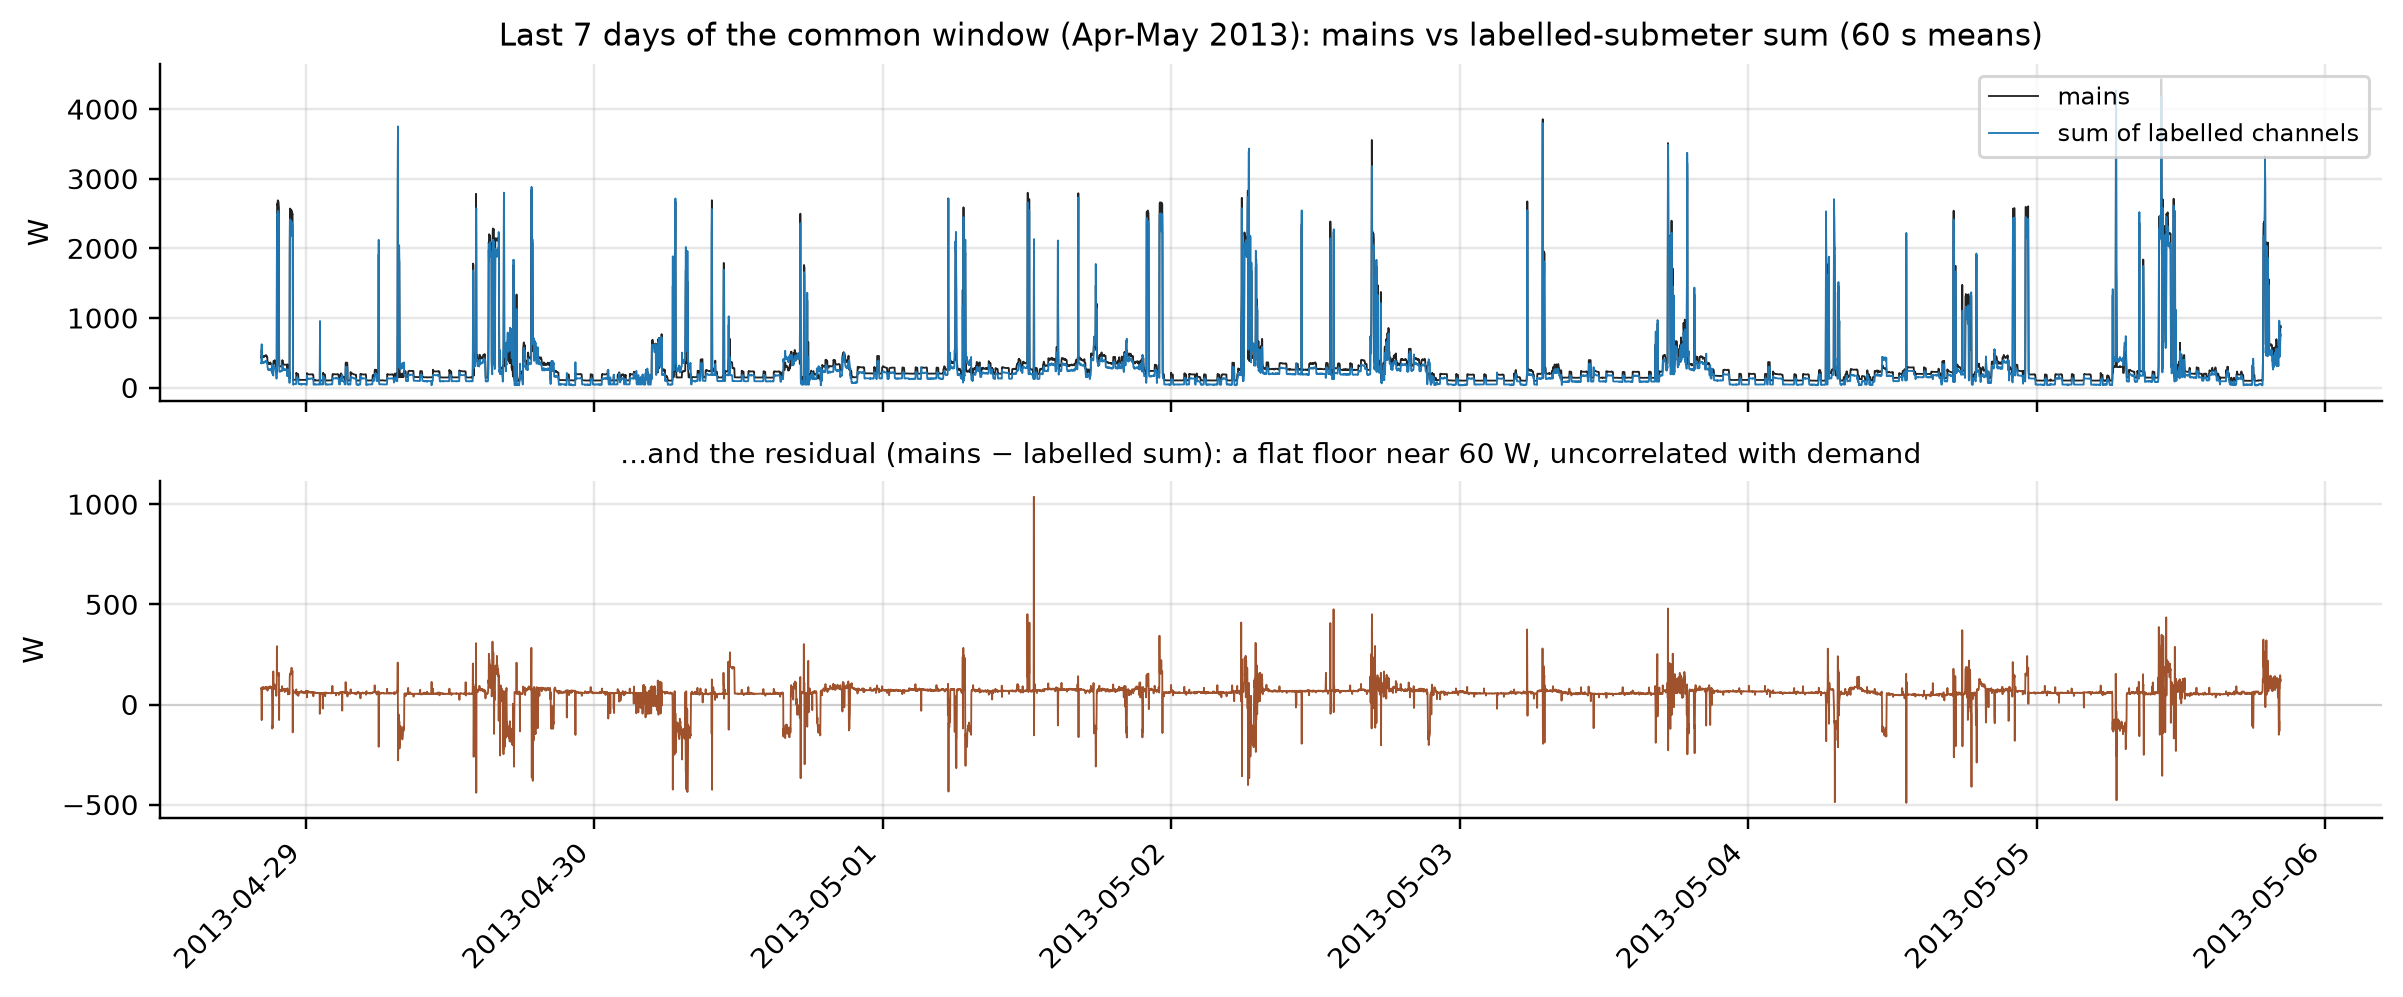

In [ ]:
w7 = 7 * 86400 * 1000000  # µs — 7 days on the µs grid
m7 = grid_u >= grid_u[-1] - w7
_fig, _ax = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
_ax[0].plot(pd.to_datetime(grid_u[m7], unit='us', utc=True), m60_v[m7], lw=0.6, label='mains', color='#222222')
_ax[0].plot(pd.to_datetime(grid_u[m7], unit='us', utc=True), sub[m7], lw=0.6, label='sum of labelled channels')
_ax[0].legend(loc='upper right')
_ax[0].set_ylabel('W')
_ax[0].set_title('Last 7 days of the common window (Apr-May 2013): mains vs labelled-submeter sum (60 s means)')
_ax[1].axhline(0, color='#cccccc', lw=0.6)
_ax[1].plot(pd.to_datetime(grid_u[m7], unit='us', utc=True), res_u[m7], lw=0.6, color='#a0522d')
_ax[1].set_ylabel('W')
_ax[1].set_title('...and the residual (mains − labelled sum): a flat floor near 60 W, uncorrelated with demand', fontsize=9)
_fig.autofmt_xdate(rotation=45)
_fig.tight_layout()
_fig  # render figure as cell output

### Coverage over four years - and what the residual is made of

One window is a sample; the question is whether coverage holds across 4.4 years and what the leftover actually is. Four more 30-day windows (mains-off minutes masked — in the July 2016 hole the submeters kept logging while the site meter was down, and an unmasked ratio would exceed 100%):

2013-04-05: 86.5% | 2014-01-11: 86.0% | 2014-11-08: 96.7% | 2015-09-04: 91.0% | 2016-06-30: 89.9%


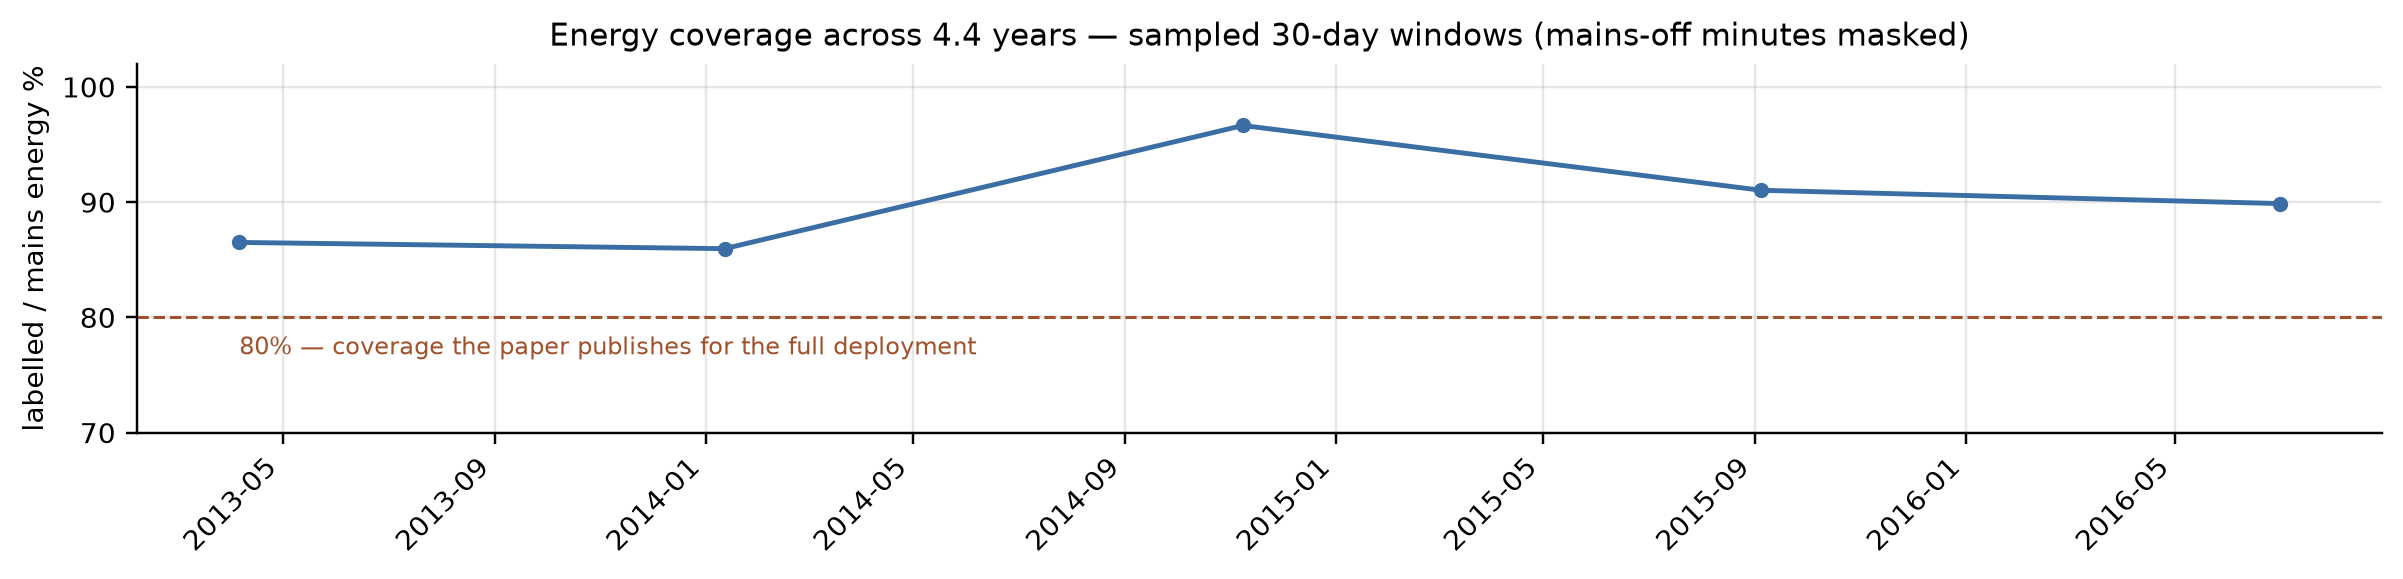

In [ ]:
cov_pts = [(pd.to_datetime(t0_common, unit='us'), 100 * cov)]
for _k in (1, 2, 3, 4):
    w0 = t0m + int(_k * (t1m - t0m) / 5)
    w1 = min(w0 + 30 * 86400 * 1000000, t1m)
    nBk = int((w1 - w0) // 60000000) + 1
    tbl_k = pq.read_table(mains_path, columns=['ts_us', 'v0'], filters=[('ts_us', '>=', w0), ('ts_us', '<=', w1)])
    _, mv_k = eda.resample_grid(tbl_k.column('ts_us').to_numpy().astype(np.int64), tbl_k.column('v0').to_numpy().astype(np.float64), 60, w0, nBk)
    del tbl_k
    fin_k = np.isfinite(mv_k)
    s_k = np.zeros(nBk)
    for _ch, (_ts, _v, _st) in ch_store.items():
        if _ch == 1:
            continue
        _, _v_g = eda.resample_grid(np.asarray(_ts), np.asarray(_v), 60, w0, nBk)
        s_k += np.nan_to_num(_v_g)
    cov_pts.append((pd.to_datetime(w0, unit='us'), 100 * float(np.nansum(s_k[fin_k]) / np.nansum(mv_k))))
_fig, _ax = plt.subplots(figsize=(11, 2.7))
_ax.plot([p[0] for p in cov_pts], [p[1] for p in cov_pts], lw=1.6, marker='o', ms=4, color='#3b6ea5', label='30-day windows (this notebook)')
_ax.axhline(80, color='#a0522d', ls='--', lw=1.0)
_ax.text(cov_pts[0][0], 80 - 3.2, '80% — coverage the paper publishes for the full deployment', fontsize=8, color='#a0522d')
_ax.set_ylim(70, 102)
_ax.set_ylabel('labelled / mains energy %')
_ax.set_title('Energy coverage across 4.4 years — sampled 30-day windows (mains-off minutes masked)')
_fig.autofmt_xdate(rotation=45)
_fig.tight_layout()
print(' | '.join(('%s: %.1f%%' % (str(p[0])[:10], p[1]) for p in cov_pts)))
_fig  # render figure as cell output

**Answer: ≈87% here, 86-97% everywhere we sample — and the leftover is the meters, not the house.** The labelled channels track the site meter closely (r = 0.975), but the remaining ≈13% is not hidden household load: the residual (bottom panel) is a **flat floor of ≈55-70 W** — night 58 W, day 53 W, **r(residual, mains) = −0.06** — a constant offset, not a load that follows activity. That matches the ~50 W self-draw of the 52 battery-powered plug meters documented in the UK-DALE paper: the IAMs eat their own measurement. Two lessons. **[insight only]:** house 1's UNKNOWN class is mostly instrumentation, so its size must not transfer to our deployment — a Shelly install's residual will be genuinely unmonitored appliances. **[collectable]:** the method transfers — every deployment needs the same mains-vs-sum books-closing with an explicit **UNKNOWN** class; what is genuinely always-on here (the ≈111 W nightly mains floor, printed above) is a separate question. Note also that sampled windows stay between 86% and 97% with no decay, while the paper publishes 80% for the full deployment — window choice moves the number more than any appliance decision, and channel 1's "aggregate" reads ≈13.7% high over the same window (printed above), so the site meter is the canonical reference.

## Q8 - What else is in the files? (and can we collect it?)

Everything above used active power only. The house 1 files carry more, and the pieces differ in purpose: some exist so we can understand the problem and will never be collectable in the target deployment; some map one-to-one onto what the planned submeters record. Every exhibit below carries a tag:

- **[insight only]** - for understanding the problem; not collectable in the target deployment and not usable for MVP experiments.
- **[collectable]** - the same quantity (or a close equivalent) can be recorded by the planned aggregate submeters.

### Voltage rides along with every reading - [collectable]

The house 1 mains file stores three columns: `v0` active watts (used everywhere above), `v1` apparent power and `v2` mains voltage. The largest spike from the opening zoom, with voltage alongside:

voltage before event: 244.7 V | min during event: 241.0 V | sag 3.7 V (1.5%)


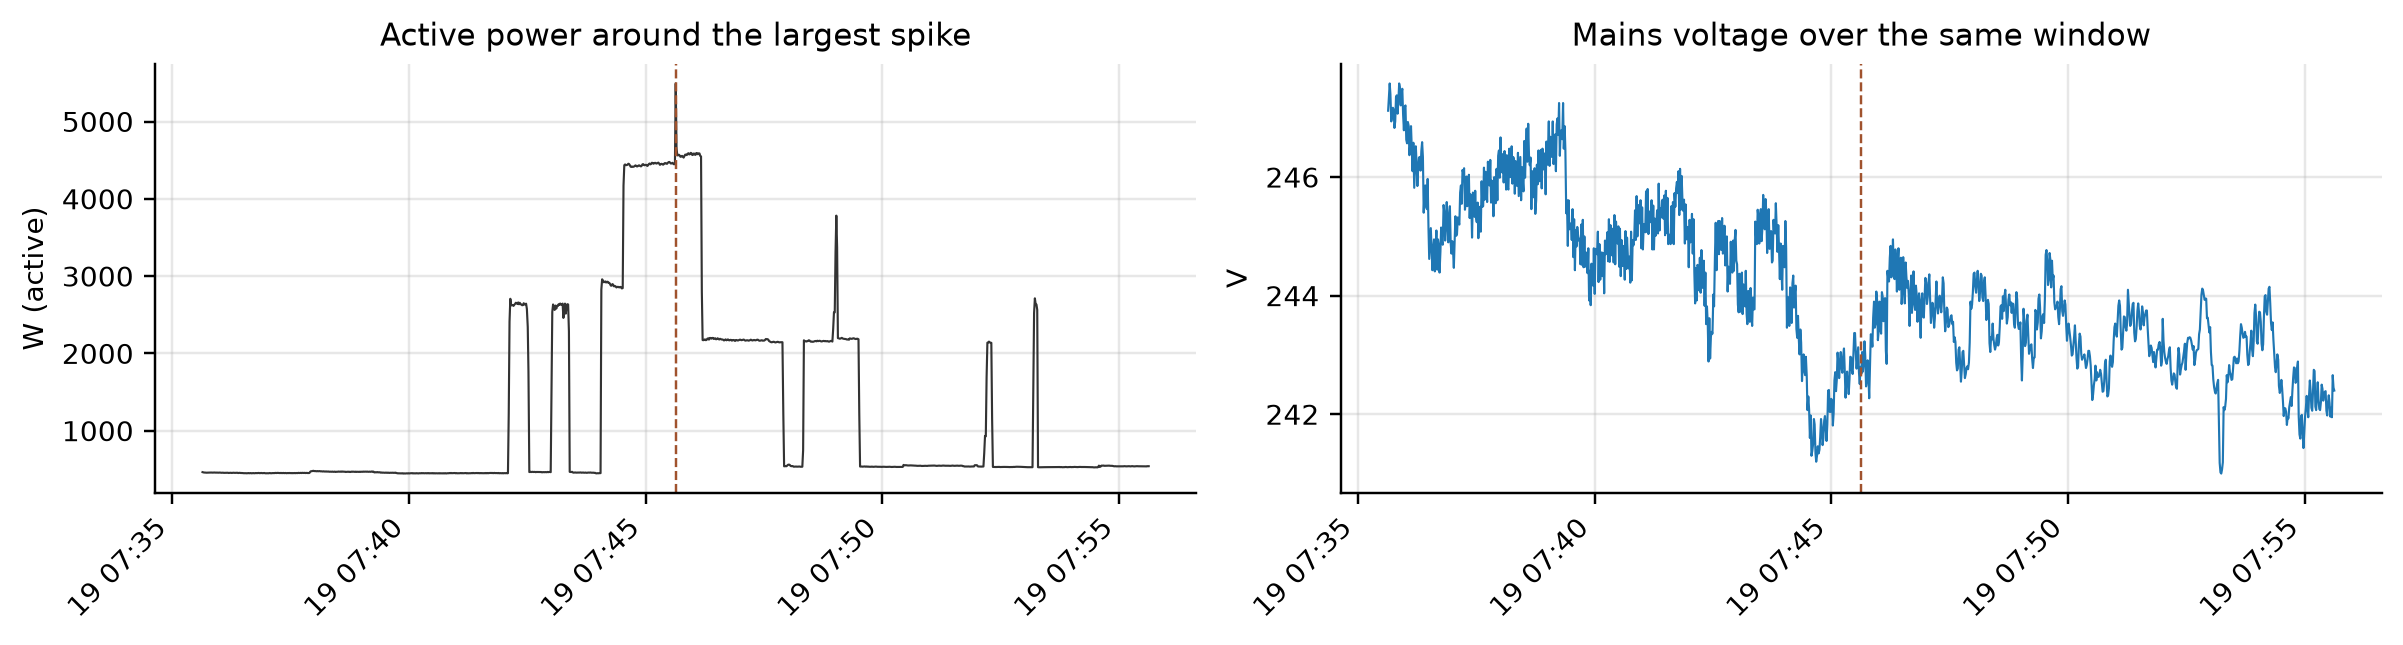

In [ ]:
zt_a, zv_a = scan['zoom']
zt = np.asarray(zt_a)
zv = np.asarray(zv_a)
tstar = int(zt[int(np.argmax(zv))])
t0v, t1v = (tstar - 10 * 60000000, tstar + 10 * 60000000)
tbl = pq.read_table(mains_path, columns=['ts_us', 'v0', 'v2'], filters=[('ts_us', '>=', t0v), ('ts_us', '<=', t1v)])
tsv = tbl.column('ts_us').to_numpy().astype(np.int64)
wv = np.nan_to_num(tbl.column('v0').to_numpy().astype(np.float64))
_vv = tbl.column('v2').to_numpy().astype(np.float64)
_fig, _ax = plt.subplots(1, 2, figsize=(11, 3.0), sharex=True)
_ax[0].plot(pd.to_datetime(tsv, unit='us'), wv, lw=0.7, color='#333333')
_ax[0].set_ylabel('W (active)')
_ax[0].set_title('Active power around the largest spike')
_ax[1].plot(pd.to_datetime(tsv, unit='us'), _vv, lw=0.7, color='#1f77b4')
_ax[1].set_ylabel('V')
_ax[1].set_title('Mains voltage over the same window')
for _a in _ax:
    _a.axvline(pd.to_datetime(tstar, unit='us'), color='#a0522d', lw=0.8, ls='--')
_fig.autofmt_xdate(rotation=45)
_fig.tight_layout()
on_w = wv > 0.3 * wv.max()
fin = np.isfinite(_vv)
low = _vv[fin & (wv < 0.1 * max(1.0, float(np.nanmax(wv))))]
v_before = float(np.nanmedian(low)) if low.size else float(np.nanmedian(_vv[fin]))
v_min = float(np.nanmin(_vv[fin & on_w])) if (fin & on_w).any() else float('nan')
sag_v = v_before - v_min
print('voltage before event: %.1f V | min during event: %.1f V | sag %.1f V (%.1f%%)' % (v_before, v_min, sag_v, 100 * sag_v / v_before))
_fig  # render figure as cell output

**Reading it [collectable].** When the big load switches on, mains voltage dips visibly (the printed line quantifies the sag) and recovers when it switches off. Load events imprint on voltage even where power signatures are ambiguous - a free secondary signal on any meter that records it. It is also why two meters on the same circuit can disagree; the project standardises on active power.

### Apparent vs active power - [collectable]

The mains file's second column, `v1`, is **apparent power** (VA). Its ratio to active power is a proxy for power factor — how much of the drawn current does real work. One representative day, sampled wherever active power exceeds 50 W:

In [ ]:
tpf0 = int(scan["t0"]) + 200 * 86400 * 1_000_000
tbl_pf = pq.read_table(mains_path, columns=["ts_us", "v0", "v1"],
                       filters=[("ts_us", ">=", tpf0), ("ts_us", "<=", tpf0 + 86400 * 1_000_000)])
v0_pf = tbl_pf.column("v0").to_numpy().astype(np.float64)
v1_pf = tbl_pf.column("v1").to_numpy().astype(np.float64)
mm_pf = (v0_pf > 50) & np.isfinite(v1_pf) & (v1_pf > 0)
rr_pf = v1_pf[mm_pf] / v0_pf[mm_pf]
pf_stats = {"p25": round(float(np.percentile(rr_pf, 25)), 2),
            "p50": round(float(np.percentile(rr_pf, 50)), 2),
            "p75": round(float(np.percentile(rr_pf, 75)), 2),
            "gt1_pct": round(100 * float((rr_pf > 1).mean()), 0)}
print("apparent / active on %s (v0 > 50 W): p25 %.2f | p50 %.2f | p75 %.2f | above 1 in %.0f%% of samples" % (
    str(pd.to_datetime(tpf0, unit="us"))[:10], pf_stats["p25"], pf_stats["p50"], pf_stats["p75"], pf_stats["gt1_pct"]))

apparent / active on 2013-10-03 (v0 > 50 W): p25 1.15 | p50 1.27 | p75 1.43 | above 1 in 100% of samples


**Reading it [collectable].** The apparent/active ratio sits near 1.27 at the median (p25 1.15, p75 1.43) and is above 1 essentially always — the house carries reactive current and pulse loads that inflate VA without doing work. A meter that reports only apparent power overstates real consumption by that factor; the project standard (active watts) is the right call, and it is derivable on any meter that records voltage and current.

### Button-press logs - human annotation - [insight only]

Alongside the power files sit 48 `channel_*_button_press.parquet` files: a resident pressed a button when switching an appliance on or off, logged as 0/1 toggles. No power at all - just timestamps and toggle state.

In [ ]:
btn_files = sorted(glob.glob(eda.fnd_file("ukdale", "house_1", "channel_*_button_press.parquet")))
rows_b = []
for f in btn_files:
    chb = int(os.path.basename(f).split("_")[1])
    rows_b.append([chb, labels.get(chb, "?"), int(pq.ParquetFile(f).metadata.num_rows)])
rows_b.sort(key=lambda r: -r[2])
exb = pq.ParquetFile(eda.fnd_file("ukdale", "house_1", "channel_12_button_press.parquet")).read(columns=["ts_us"])
ext = pd.to_datetime(exb.column("ts_us").to_numpy(), unit="us")
print("example - fridge (ch12): %d toggles between %s and %s" % (len(ext), ext[0], ext[-1]))
mo.md(eda.md_table(["ch", "label", "toggle rows"], rows_b[:10]))

example - fridge (ch12): 335 toggles between 2013-03-20 11:41:24 and 2017-03-19 09:29:33


| ch | label | toggle rows |
| --- | --- | --- |
| 34 | samsung_charger | 2151 |
| 29 | livingroom_lamp_tv | 1647 |
| 26 | livingroom_s_lamp2 | 1386 |
| 24 | bedroom_ds_lamp | 1318 |
| 45 | childs_ds_lamp | 1169 |
| 19 | livingroom_s_lamp | 1118 |
| 49 | office_lamp2 | 968 |
| 33 | utilityrm_lamp | 924 |
| 43 | data_logger_pc | 777 |
| 48 | office_lamp1 | 592 |

**Reading it [insight only].** Even the fridge - used every day - earned only a few hundred toggles in 4.5 years; most channels got fewer. Manual labelling at this scale is a research luxury, not something a deployed pipeline can rely on: ground truth has to come from instrumentation or be inferred. The button logs show how little human-in-the-loop annotation actually yields.

### When meters lie: implausible maxima - [insight only]

Small loads report sporadic spikes near 4 kW that the device cannot draw. The screen: channels whose median ON draw is under 150 W but which record readings above 2 kW in fewer than 0.1% of samples (the dishwasher's real 2 kW heater fails this filter in the right way — too many high readings to be noise):

In [ ]:
rows_sp = []
for _ch, (_ts, _v, _st) in ch_store.items():
    if _ch == 1 or not len(_v):
        continue
    _vv = np.asarray(_v)
    if float(_st['vmax']) > 2000 and float(_st['p50_on_w']) < 150 and (float((_vv > 2000).mean()) < 0.001):
        rows_sp.append([int(_ch), _st['label'], round(float(_st['vmax'])), round(float(_st['p50_on_w']), 1), int((_vv > 2000).sum())])
rows_sp.sort(key=lambda r: -r[2])
print('%d channels pass the spurious-spike screen' % len(rows_sp))
mo.md(eda.md_table(['ch', 'label', 'max W', 'p50 ON W', 'readings > 2 kW'], rows_sp))

25 channels pass the spurious-spike screen


| ch | label | max W | p50 ON W | readings > 2 kW |
| --- | --- | --- | --- | --- |
| 44 | childs_table_lamp | 3993 | 14.0 | 23 |
| 35 | bedroom_d_lamp | 3973 | 26.0 | 9 |
| 38 | bedroom_chargers | 3935 | 8.0 | 4 |
| 50 | office_lamp3 | 3860 | 7.0 | 2 |
| 45 | childs_ds_lamp | 3795 | 8.0 | 19 |
| 31 | kitchen_lamp2 | 3760 | 18.0 | 7 |
| 52 | office_fan | 3746 | 32.0 | 1 |
| 28 | subwoofer_livingroom | 3654 | 16.0 | 13 |
| 36 | coffee_machine | 3567 | 52.0 | 14 |
| 27 | iPad_charger | 3504 | 8.0 | 11 |
| 34 | samsung_charger | 3496 | 6.0 | 3 |
| 12 | fridge | 3323 | 89.0 | 13 |
| 48 | office_lamp1 | 3220 | 14.0 | 5 |
| 15 | hifi_office | 3131 | 9.0 | 3 |
| 7 | tv | 3109 | 103.0 | 2 |
| 32 | kitchen_phone&stereo | 2894 | 20.0 | 3 |
| 49 | office_lamp2 | 2405 | 11.0 | 3 |
| 53 | LED_printer | 2242 | 6.0 | 2 |
| 23 | kitchen_dt_lamp | 2215 | 41.0 | 1 |
| 19 | livingroom_s_lamp | 2144 | 16.0 | 1 |
| 2 | boiler | 2060 | 12.0 | 2 |
| 21 | gigE_&_USBhub | 2058 | 9.0 | 1 |
| 37 | kitchen_radio | 2049 | 129.0 | 2 |
| 3 | solar_thermal_pump | 2048 | 48.0 | 2 |
| 47 | battery_charger | 2048 | 11.0 | 3 |

**Reading it [insight only].** A table lamp tops the list at 3,993 W — the UK-DALE paper itself notes IAM readings up to ~4 kW are RF artefacts, and its authors filter values above 4 kW. 25 house 1 channels show the pattern: maxima far above any physical draw for the device, a handful of samples each. The fridge's 3,323 W spike (13 samples) is the same effect on a trusted channel. Lesson for the target deployment: screen `max / median-ON` before trusting any peak, and never let one spurious sample set a scaling range.

### 16 kHz V-I snippets - [insight only]

Beyond the power columns, the UK-DALE project published raw 16 kHz voltage-current capture windows for some houses. We hold none of it in `data/fnd/` (the V-I track under `research-logs/vi/` collects the equivalent idea for PLAID); it matters here as a pointer: high-rate V-I is what waveform-level appliance identification builds on — far beyond what an aggregate-only deployment can use, but the ceiling of what appliance identification could ever see.

### The other four houses - same questions, different answers

House 1 got the deep dive because it is the richest. The fleet view: houses 2 and 5 also recorded a dedicated site meter (the quantity the target deployment records - **[collectable]**); houses 3 and 4 recorded their aggregate as an ordinary 6-second channel instead (**[insight only]**). Do the earlier answers transfer?

In [ ]:
rows_h = []
h2_notes = []
for _hd in house_dirs:
    hn = os.path.basename(_hd)
    lab_h = eda.read_labels_dat(os.path.join(_hd, 'labels.dat'))
    canon_h = sorted(set(lab_h.values()) & set(eda.CANON))
    mp = os.path.join(_hd, 'mains.parquet')
    _span_d = mean_w = kwh = fduty = float('nan')
    if os.path.exists(mp):
        sc_h = eda.scan_power_series(mp, value_col='v0', local_offset_hours=0)
        _span_d, mean_w, kwh = (sc_h['span_days'], sc_h['mean_w'], sc_h['energy_kwh'])
    fr = [c for c, l in lab_h.items() if 'fridge' in l]
    for _c in fr:
        pfr = os.path.join(_hd, 'channel_%d.parquet' % _c)
        if os.path.exists(pfr):
            tfr, vfr = eda.read_channel(pfr, 'v0')
            stfr_l = eda.channel_stats(tfr, vfr, missing_values=())
            stfr_f = eda.channel_stats(tfr, vfr, missing_values=(), thr_rule='floor')
            fduty = 100 * float(stfr_f['on_share'])
            if 100 * float(stfr_l['on_share']) > 99:
                h2_notes.append((hn, _c, lab_h.get(_c, '?'), float(stfr_f['floor_w']), 100 * float(stfr_l['on_share']), fduty))
            del tfr, vfr
    rows_h.append([hn, 'yes' if os.path.exists(mp) else 'no', '%.0f' % _span_d if _span_d == _span_d else '-', '%.0f' % mean_w if mean_w == mean_w else '-', '%.0f' % kwh if kwh == kwh else '-', ', '.join(canon_h) if canon_h else '-', '%.1f' % fduty if fduty == fduty else '-'])
for hn2, c2, l2, fl2, d_l2, d_f2 in h2_notes:
    print("%s fridge (ch%d '%s'): sensor floor %.0f W -> plain-rule duty %.1f%% (always-ON artifact); floor-aware duty %.1f%%" % (hn2, c2, l2, fl2, d_l2, d_f2))
mo.md(eda.md_table(['house', 'mains', 'span d', 'mean W', 'kWh', 'canonical present', 'fridge duty % (floor-aware)'], rows_h))

house_2 fridge (ch14 'fridge'): sensor floor 10 W -> plain-rule duty 100.0% (always-ON artifact); floor-aware duty 44.6%


| house | mains | span d | mean W | kWh | canonical present | fridge duty % (floor-aware) |
| --- | --- | --- | --- | --- | --- | --- |
| house_1 | yes | 1501 | 343 | 12268 | dishwasher, fridge, kettle, microwave, washing_machine | 42.2 |
| house_2 | yes | 176 | 299 | 1328 | fridge, kettle, microwave, washing_machine | 44.6 |
| house_3 | no | - | - | - | kettle | - |
| house_4 | no | - | - | - | - | - |
| house_5 | yes | 137 | 572 | 1878 | dishwasher, kettle, microwave | 35.6 |

**Reading it.** The canonical targets are not uniformly present: houses 2 and 5 carry four of the five, house 3 only a kettle, house 4 a single combo channel that merges several appliances into one meter. Even the names differ across houses (`dish_washer` vs `dishwasher`, `fridge_freezer`, `washer_dryer`) - label normalisation is part of the job. Where a fridge is separately metered, its duty differs from house 1's 42%: house 2's compressor runs ~45% of the time under the floor-aware rule — but the **plain rule reported 100%**, because that sensor idles at ~10 W and the rule's 5 W threshold never clears (printed under the table). Same appliance class, different home, different behaviour - and a threshold rule that must be checked against each sensor's idle floor. Multi-home datasets carry this friction, and models have to be robust to it.

## Quirks & gotchas

- **Houses 3 and 4 have no dedicated 1 s mains file** — their aggregate is an ordinary channel (channel 1) at ~6-8 s cadence; useful as label-only context and low-rate practice, not for 1 s aggregate work.
- **Channel 1 is the aggregate itself** (label collision in `labels.dat`) — never sum it against the mains.
- Appliance channels run at **~6 s**: kettle inrush is smeared; episode timing carries ~6 s jitter. The mains is 1 s.
- **Duplicate labels** exist (two "light" channels) — treat them as separate meters of one appliance class.
- **Washer meter catches 14 s control draws** (18.7 episodes/day); long real cycles dominate its energy.
- **Mains holes: 10 d Jul 2016, 4 d Mar 2016** plus three evening dropouts — gate training rows around them.
- The mains also carries apparent power (v1) and voltage (v2); v0 (active W) is the NILM quantity, v2 allows voltage-sag studies.
- **Button-press logs** are sparse point events, not power series.
- `labels.dat` may list channels with no Parquet file (and vice versa); the inventory handles both.
- **ON-rule artifact on standing-draw sensors**: a meter idling at ~10 W (house 2's fridge) never clears the 5 W threshold, so the plain rule reads "always ON" (100% duty). The floor-aware rule (`thr = floor + max(5, 0.5*(p50_on - floor))`) fixes it; check every sensor's idle level before trusting duty.
- **Spurious ~4 kW readings**: 25 house 1 channels report sporadic RF artefacts up to 3,993 W (screen in Q8); the paper's authors filter above 4 kW.
- **Use-only meters**: iron (0.0% of the window), straighteners (0.2%), hoover (0.7%), hair_dryer (1.0%) record only while in use — their energy covers recorded periods only, and OFF is indistinguishable from "logger parked".
- **No sentinel values**: UK-DALE writes plain 0 W for off (no negatives in any house 1 channel); ECO (notebook 04) uses -1 — check per dataset before applying `missing_values`.
- **Times are UTC**: hour-of-day peaks are UTC; London runs UTC+1 in British Summer Time (late Mar-late Oct), so local-clock peaks shift one hour in summer exhibits.
- **Sub-2-minute dropouts are not OFF**: the paper treats IAM gaps under two minutes as non-recording; the same convention applies to the 6 s channels (a >2 min gap is missing data, not the appliance switching off).

## Verdict — what is this dataset good for?

**The primary training and evaluation substrate.** 4.1 years of 1 s aggregate plus 53 labelled 6 s channels; all five canonical targets present with clean ground truth (34% of the bill between them, computed over the mains window); a stationary fridge anchor (Q4); mild repeatable seasonality (Q5); realistic overlap - 3.2% of minutes, but roughly half of events start inside a mix (Q6); a residual that is the meters' own draw, not hidden load (Q7); and step-size structure a model must survive (the kettle's median switch-on step is ≈225 W, not its 2.3 kW level, Q3). The gaps are documented and avoidable. Start every modelling question here.

A note on purpose: the appliance channels, button logs and voltage columns exist so we can understand what an aggregate-only deployment cannot see - they are **[insight only]**. The aggregate feed itself is **[collectable]**. What this dataset teaches about cadence, gaps, labelling and the un-metered residual is exactly what to get right when recording our own.

In [ ]:
hourly_peaks = {c: int(int(np.argmax(hp[c]))) for c in hp}
SUMMARY = {
    "dataset": "ukdale",
    "houses": [[h[0], int(h[1]), int(rt)] for h, rt in zip(inv, inv_rows_total)],
    "mains_house_1": {
        "rows": int(scan["n"]), "span_days": round(scan["span_days"], 1), "dt_med_s": round(scan["dt_med_s"], 2),
        "mean_w": round(scan["mean_w"], 1), "p50_w": round(scan["quantiles"]["p50"], 1),
        "p95_w": round(scan["quantiles"]["p95"], 1), "p99_w": round(scan["quantiles"]["p99"], 1),
        "max_w": round(scan["vmax"], 0), "energy_kwh": round(scan["energy_kwh"], 1),
        "steps_per_day_ge100w": round(scan["steps"][100] / scan["span_days"], 1),
    },
    "gaps_house_1_mains": {
        "n_gt_60s": int(len(gaps)), "total_missing_days": round(tot_d, 2),
        "biggest": [["%.1f h" % (g / 3.6e9), str(pd.to_datetime(t, unit="us"))[:10]] for g, t in gaps[:3]],
    },
    "channels_house_1": int(len(cdf)),
    "top_energy_channels": [[r.label, int(r.ch), round(float(r.energy_kwh), 1)]
                            for r in cdf[cdf.ch != 1].head(8).itertuples()],
    "canonical": [[r.label, int(r.ch), round(float(r.p50_on_w), 1), round(float(r.thr_on_w), 1),
                   round(100 * float(r.on_share), 1), round(float(r.episodes_per_day), 1)]
                  for r in canon_rows.itertuples()],
    "canonical_share_pct": round(100 * float(canon_rows.energy_kwh.sum() / scan["energy_kwh"]), 1),
    "fridge_weekly_duty": {"mean_pct": round(float(np.nanmean(duty_w)), 1),
                           "p5": round(float(np.nanpercentile(duty_w, 5)), 1),
                           "p95": round(float(np.nanpercentile(duty_w, 95)), 1), "weeks": int(len(uw))},
    "seasonality": {"winter_mean_kwh": round(float(np.mean(winter)), 1),
                    "summer_mean_kwh": round(float(np.mean(summer)), 1),
                    "ratio": round(season_ratio, 2)},
    "hourly_on_peak_hour": hourly_peaks,
    "simultaneity_two_plus_pct": round(100 * sim["two_plus"], 1),
    "energy_coverage_pct": round(100 * cov, 1),
    "energy_method": "timestamp-integrated over the mains window, per-sample carry-over capped at 3x cadence",
    "residual_30d": {"mean_w": round(float(np.nanmean(res_u[fin_r])), 1),
                     "p25_w": round(float(np.nanpercentile(res_u[fin_r], 25)), 1),
                     "p75_w": round(float(np.nanpercentile(res_u[fin_r], 75)), 1),
                     "night_mean_w": round(float(np.nanmean(res_u[night_m])), 1),
                     "day_mean_w": round(float(np.nanmean(res_u[day_m])), 1),
                     "r_labelled_mains": round(float(np.corrcoef(sub[fin_r], m60_v[fin_r])[0, 1]), 3),
                     "r_residual_mains": round(float(np.corrcoef(res_u[fin_r], m60_v[fin_r])[0, 1]), 3),
                     "neg_pct": round(100 * float((res_u[fin_r] < 0).mean()), 1),
                     "nightly_floor_w": round(floor_night, 0)},
    "coverage_windows_pct": [[str(p[0])[:10], round(p[1], 1)] for p in cov_pts],
    "published_coverage_pct": 80,
    "event_cooccurrence_pct": ev_pct,
    "dp_p50_w": {r[0]: int(r[4]) for r in dp_rows},
    "power_factor_1d": pf_stats,
    "weekday_weekend_ratio": round(float(weekend_mean / weekday_mean), 2),
    "ch1_vs_mains_30d_pct": round(100 * (kwh_ch1_cw - kwh_mains_cw) / kwh_mains_cw, 1),
    "implausible_max_channels": int(len(rows_sp)),
    "low_recording_channels": [[int(c), l, p] for c, l, p in low_rec],
    "defrost_share_of_on_pct": round(float(defrost_share), 1),
    "voltage_sag": {"v_before": round(v_before, 1), "v_min": round(v_min, 1), "sag_v": round(sag_v, 1)},
    "button_press_files_house_1": int(len(btn_files)),
    "houses_mains": [[r[0], r[1], r[2], r[3], r[4]] for r in rows_h],
    "fridge_duty_pct_per_house": {r[0]: r[6] for r in rows_h},
    "lighting_longest_on_days": round(dur_l_d, 2),
    "boiler_longest_on_h": round(dur_b_h, 1),
}
mo.md(eda.md_summary(SUMMARY))

**Summary**

| metric | value |
| --- | --- |
| dataset | ukdale |
| rows | - |
| span | - |
| cadence | - |
| power W (mean / p50 / p95) | - |
| energy | - |
| simultaneity (2+ ON) | 3.2% of 60 s buckets |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "dataset": "ukdale",
  "houses": [
    [
      "house_1",
      53,
      728877165
    ],
    [
      "house_2",
      19,
      40506387
    ],
    [
      "house_3",
      5,
      2581158
    ],
    [
      "house_4",
      6,
      13088208
    ],
    [
      "house_5",
      25,
      33903991
    ]
  ],
  "mains_house_1": {
    "rows": 128238700,
    "span_days": 1500.9,
    "dt_med_s": 1.0,
    "mean_w": 342.5,
    "p50_w": 223.3,
    "p95_w": 693.3,
    "p99_w": 2710.7,
    "max_w": 8066.0,
    "energy_kwh": 12268.0,
    "steps_per_day_ge100w": 709.9
  },
  "gaps_house_1_mains": {
    "n_gt_60s": 21,
    "total_missing_days": 18.46,
    "biggest": [
      [
        "245.8 h",
        "2016-07-21"
      ],
      [
        "102.1 h",
        "2016-03-24"
      ],
      [
        "43.7 h",
        "2013-04-01"
      ]
    ]
  },
  "channels_house_1": 53,
  "top_energy_channels": [
    [
      "fridge",
      12,
      1441.2
    ],
    [
      "lighting_circuit",
      25,
      1034.0
    ],
    [
      "dishwasher",
      6,
      964.8
    ],
    [
      "washing_machine",
      5,
      959.9
    ],
    [
      "kitchen_lights",
      8,
      716.7
    ],
    [
      "htpc",
      9,
      680.5
    ],
    [
      "boiler",
      2,
      643.3
    ],
    [
      "kettle",
      10,
      565.3
    ]
  ],
  "canonical": [
    [
      "fridge",
      12,
      89.0,
      44.5,
      42.4,
      25.3
    ],
    [
      "dishwasher",
      6,
      121.0,
      60.5,
      2.6,
      1.8
    ],
    [
      "washing_machine",
      5,
      177.0,
      88.5,
      3.4,
      19.4
    ],
    [
      "kettle",
      10,
      2347.0,
      1173.5,
      0.7,
      4.8
    ],
    [
      "microwave",
      13,
      1523.0,
      761.5,
      0.5,
      6.5
    ]
  ],
  "canonical_share_pct": 34.4,
  "fridge_weekly_duty": {
    "mean_pct": 42.4,
    "p5": 35.0,
    "p95": 49.6,
    "weeks": 215
  },
  "seasonality": {
    "winter_mean_kwh": 279.3,
    "summer_mean_kwh": 208.1,
    "ratio": 1.34
  },
  "hourly_on_peak_hour": {
    "fridge": 17,
    "dishwasher": 22,
    "washing_machine": 10,
    "kettle": 7,
    "microwave": 7
  },
  "simultaneity_two_plus_pct": 3.2,
  "energy_coverage_pct": 86.5,
  "energy_method": "timestamp-integrated over the mains window, per-sample carry-over capped at 3x cadence",
  "residual_30d": {
    "mean_w": 44.9,
    "p25_w": 56.0,
    "p75_w": 70.4,
    "night_mean_w": 58.0,
    "day_mean_w": 53.3,
    "r_labelled_mains": 0.975,
    "r_residual_mains": -0.06,
    "neg_pct": 8.9,
    "nightly_floor_w": 111.0
  },
  "coverage_windows_pct": [
    [
      "2013-04-05",
      86.5
    ],
    [
      "2014-01-11",
      86.0
    ],
    [
      "2014-11-08",
      96.7
    ],
    [
      "2015-09-04",
      91.0
    ],
    [
      "2016-06-30",
      89.9
    ]
  ],
  "published_coverage_pct": 80,
  "event_cooccurrence_pct": {
    "fridge": 6.7,
    "dishwasher": 48.0,
    "washing_machine": 51.0,
    "kettle": 52.0,
    "microwave": 56.1
  },
  "dp_p50_w": {
    "iron": 1778,
    "toaster": 1545,
    "microwave": 1323,
    "kettle": 225,
    "washing_machine": 113,
    "fridge": 102,
    "dishwasher": 38
  },
  "power_factor_1d": {
    "p25": 1.15,
    "p50": 1.27,
    "p75": 1.43,
    "gt1_pct": 100.0
  },
  "weekday_weekend_ratio": 0.96,
  "ch1_vs_mains_30d_pct": 13.7,
  "implausible_max_channels": 25,
  "low_recording_channels": [
    [
      22,
      "hoover",
      0.7
    ],
    [
      39,
      "hair_dryer",
      1.0
    ],
    [
      40,
      "straighteners",
      0.2
    ],
    [
      41,
      "iron",
      0.0
    ],
    [
      20,
      "soldering_iron",
      2.4
    ],
    [
      30,
      "DAB_radio_livingroom",
      3.2
    ]
  ],
  "defrost_share_of_on_pct": 2.9,
  "voltage_sag": {
    "v_before": 244.7,
    "v_min": 241.0,
    "sag_v": 3.7
  },
  "button_press_files_house_1": 48,
  "houses_mains": [
    [
      "house_1",
      "yes",
      "1501",
      "343",
      "12268"
    ],
    [
      "house_2",
      "yes",
      "176",
      "299",
      "1328"
    ],
    [
      "house_3",
      "no",
      "-",
      "-",
      "-"
    ],
    [
      "house_4",
      "no",
      "-",
      "-",
      "-"
    ],
    [
      "house_5",
      "yes",
      "137",
      "572",
      "1878"
    ]
  ],
  "fridge_duty_pct_per_house": {
    "house_1": "42.2",
    "house_2": "44.6",
    "house_3": "-",
    "house_4": "-",
    "house_5": "35.6"
  },
  "lighting_longest_on_days": 7.84,
  "boiler_longest_on_h": 770.7
}
```

</details>